# Transfer Learning Lab
**Name:** Myles Miller, Chris Hirschbrich, Blake Green

**Date:** 3/22/26

In [ ]:
# -- Imports -----------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, accuracy_score
)
import warnings
warnings.filterwarnings('ignore')

# Deep learning (swap for PyTorch equivalents if preferred)
import tensorflow as tf
from tensorflow import keras
print('TF version:', tf.__version__)

TF version: 2.19.0


In [ ]:
# -- Mount Google Drive -----------------------------------------------
from google.colab import drive
drive.mount('/content/drive')

import kagglehub
import os

# Download dataset
path = kagglehub.dataset_download("iarunava/cell-images-for-detecting-malaria")
print("Path to dataset files:", path)

# Check folder structure
for root, dirs, files in os.walk(path):
    depth = root.replace(path, '').count(os.sep)
    if depth < 3:
        indent = ' ' * 2 * depth
        print(f"{indent}{os.path.basename(root)}/  ({len(files)} files)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using Colab cache for faster access to the 'cell-images-for-detecting-malaria' dataset.
Path to dataset files: /kaggle/input/cell-images-for-detecting-malaria
cell-images-for-detecting-malaria/  (0 files)
  cell_images/  (0 files)
    Uninfected/  (13780 files)
    Parasitized/  (13780 files)
    cell_images/  (0 files)


---
## Section 1 — Dataset Overview

### 1.1 Classification Task & Business Case
> - The classification task is binary classification: given a single segmented red blood cell image, the model predicts whether the cell is parasitized or uninfected. Each image receives exactly one of two mutually exclusive labels, so this is neither multi-class nor multi-label.
> - The real-world problem this solves is the manual microscopic screening of blood smears for a malaria diagnosis. The current standard diagnostic procedure requires a trained microscopist to visually examine Giemsa-stained thin blood smear slides under a microscope, identifying parasitized cells among thousands of healthy ones. This process is time-consuming (10-15 minutes per slide), can be error-prone when technicians are tired, and critically dependent on examiner expertise, which is scarce in the resource constrained regions where malaria is most prevalent like Sub-Saharan Africa. An automated classifier that can reliably distinguish parasitized from uninfected cells directly benefits frontline healthcare workers and patients in areas like sub-Saharan Africa, Southeast Asia, and South Asia by accelerating screening throughput, reducing diagnostic errors, and enabling deployment on cheap smartphones attached to standard light microscopes. The Lister Hill National Center for Biomedical Communications team at National Library of Medicine built this dataset specifically to support such a mobile screening tool, meaning the classification task maps directly onto a deployed clinical application.
> - This is not multi-task learning. The model optimizes a single objective which is binary cell-level classification. There is one shared output head and one loss function. There is no auxiliary task being learned jointly. The segmentation step that isolates individual cells from full-field microscopy images was handled upstream via a level-set algorithm before the classification dataset was constructed, so it does not factor into the model's learning objective.

### 1.2 Feature Data — Provenance & Modality
> - The input features are RGB color images of individual red blood cells stored as PNG files. Each image contains a single segmented cell extracted from a Giemsa-stained thin blood smear slide photograph. The images have three color channels (red, green, blue), however, they are not a uniform resolution so preprocessing must resize them to a consistent shape before being fed into a model. The cell-level images were produced by applying a level-set segmentation algorithm to full-field microscope photographs, isolating each red blood cell from the broader slide. Labels are encoded implicitly by directory structure: images live under either a Parasitized/ or Uninfected/ folder rather than in a separate annotation file.
> - The data was collected by researchers at the Lister Hill National Center for Biomedical Communications (LHNCBC), part of the National Library of Medicine (NLM) at the National Institutes of Health (NIH). Giemsa-stained thin blood smear slides from 150 Plasmodium falciparum-infected patients and 50 healthy patients were collected and photographed at Chittagong Medical College Hospital in Bangladesh. An Android smartphone attached to a conventional light microscope captured images of slides for each microscopic field of view. The images were then manually annotated by an expert slide reader at the Mahidol-Oxford Tropical Medicine Research Unit in Bangkok, Thailand. The de-identified images and annotations are archived at NLM under IRB #12972. The associated reference paper is Rajaraman et al. (2018), published in PeerJ (volume 6, e4568). The purpose of the data collection was to support the development of the "Malaria Screener" mobile application, aiming to reduce the diagnostic burden on microscopists in resource-constrained regions and improve screening accuracy through automated computer-aided diagnosis.
> - The data is not multi-modal. It consists exclusively of single-cell microscopy images organized into two class folders (Parasitized and Uninfected), with no accompanying tabular metadata, text, audio, or time-series signals. Classification labels are encoded implicitly by directory structure rather than a separate label file.

Prompt:
"Write Python code to load and inspect the NIH Malaria Cell Images dataset from a local directory. Count the number of images in each class (Parasitized and Uninfected), print the totals, and compute summary statistics (min, max, mean) for image widths and heights by sampling 400 images."

In [ ]:
# -- Load & inspect dataset -----------------------------------------------
import os
from pathlib import Path
from PIL import Image
import numpy as np

DATA_DIR = Path(path) / "cell_images" / "cell_images"

parasitized_dir = DATA_DIR / "Parasitized"
uninfected_dir  = DATA_DIR / "Uninfected"

para_files = [f for f in parasitized_dir.iterdir() if f.suffix == ".png"]
uninf_files = [f for f in uninfected_dir.iterdir() if f.suffix == ".png"]

print(f"Parasitized images : {len(para_files)}")
print(f"Uninfected images  : {len(uninf_files)}")
print(f"Total images       : {len(para_files) + len(uninf_files)}")

sample_sizes = []
for img_path in para_files[:200] + uninf_files[:200]:
    with Image.open(img_path) as img:
        sample_sizes.append(img.size)

widths, heights = zip(*sample_sizes)
print(f"\nSample image size stats (n=400):")
print(f"  Width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}")
print(f"  Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}")
print(f"  Channels: 3 (RGB)")

Parasitized images : 13779
Uninfected images  : 13779
Total images       : 27558

Sample image size stats (n=400):
  Width  — min: 67, max: 211, mean: 132
  Height — min: 70, max: 223, mean: 132
  Channels: 3 (RGB)


Prompt:
"Write Python code to create two exploratory visualizations for the malaria cell image dataset: a bar chart showing the class distribution between Parasitized and Uninfected, and a 2x3 grid displaying random sample images from each class resized to 128x128."

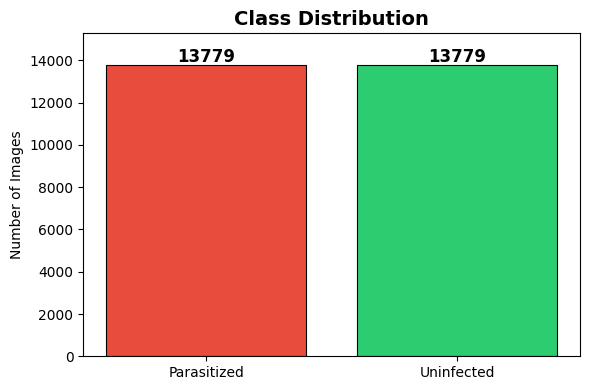

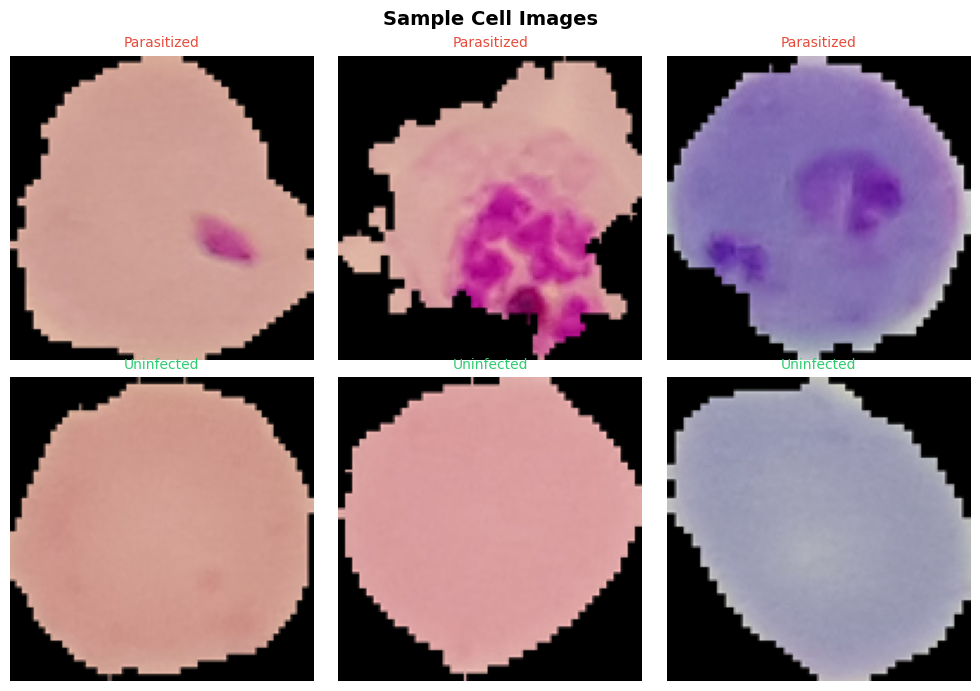

In [ ]:
# -- Exploratory visualisations -----------------------------------------------
import matplotlib.pyplot as plt
import random

# --- Class distribution bar chart ---
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
classes = ["Parasitized", "Uninfected"]
counts  = [len(para_files), len(uninf_files)]
colors  = ["#e74c3c", "#2ecc71"]

ax.bar(classes, counts, color=colors, edgecolor="black", linewidth=0.8)
ax.set_title("Class Distribution", fontsize=14, fontweight="bold")
ax.set_ylabel("Number of Images")
for i, v in enumerate(counts):
    ax.text(i, v + 150, str(v), ha="center", fontsize=12, fontweight="bold")
ax.set_ylim(0, max(counts) + 1500)
plt.tight_layout()
plt.show()

# --- Sample cell images (3 parasitized, 3 uninfected) ---
fig, grid_axes = plt.subplots(2, 3, figsize=(10, 7))
sample_para  = random.sample(para_files, 3)
sample_uninf = random.sample(uninf_files, 3)

for col, img_path in enumerate(sample_para):
    img = Image.open(img_path).resize((128, 128))
    grid_axes[0, col].imshow(img)
    grid_axes[0, col].set_title("Parasitized", fontsize=10, color="#e74c3c")
    grid_axes[0, col].axis("off")

for col, img_path in enumerate(sample_uninf):
    img = Image.open(img_path).resize((128, 128))
    grid_axes[1, col].imshow(img)
    grid_axes[1, col].set_title("Uninfected", fontsize=10, color="#2ecc71")
    grid_axes[1, col].axis("off")

plt.suptitle("Sample Cell Images", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 1.3 Evaluation Criteria
> - The primary evaluation metric will be accuracy, which is appropriate here because the dataset is perfectly balanced, 13,779 parasitized and 13,779 uninfected images, meaning accuracy is not distorted by class imbalance. In a balanced setting, accuracy gives a straightforward and interpretable measure of overall model correctness: what proportion of all cell images does the model classify correctly? This aligns directly with the clinical use case, where a microscopist needs to get the right answer on as many cells as possible across both classes.
> - Accuracy alone does not capture the asymmetric costs of different error types in a medical screening context. A false negative, classifying a parasitized cell as uninfected, is clinically more dangerous than a false positive, because a missed infection could delay treatment and lead to severe complications or death. Conversely, a false positive leads to unnecessary follow-up testing but does not endanger the patient. For this reason, recall (sensitivity) will be reported as a key secondary metric, since it directly measures the model's ability to catch parasitized cells and avoid missed infections. Precision will also be reported to quantify how many of the model's positive predictions are actually correct, and the F1 score will be included as a single number that balances precision and recall. Together, these secondary metrics give a more complete picture of model behavior than accuracy alone. Finally, a confusion matrix will be visualized to make the raw counts of true positives, true negatives, false positives, and false negatives transparent. This is useful for communicating results to clinical stakeholders who need to understand exactly where the model succeeds and fails.
> - This evaluation strategy supports the business case because the end goal is deployment in a mobile screening tool used by healthcare workers in resource constrained settings. Accuracy confirms overall reliability, recall ensures infected patients are not missed, and the confusion matrix provides the transparency needed for clinical trust and regulatory review.

---
## Section 2 — Foundational Model Description

> - The foundational model we will use is DeiT-tiny-patch16-224 (Data-efficient Image Transformer, tiny variant, patch size 16, 224x224 input). DeiT belongs to the Vision Transformer (ViT) family but was specifically engineered by Facebook AI Research to be far more data and compute efficient than the original ViT. While the original ViT required pre-training on massive proprietary datasets to perform well, DeiT achieves competitive results training only on ImageNet-1k (1.28 million images, 1,000 classes) by introducing a knowledge distillation strategy and stronger data augmentation during training. This makes DeiT a much more practical foundation for fine-tuning in resource-constrained settings like our lab running on Colab.
> - DeiT-tiny was trained on the ImageNet-1k dataset via supervised classification: given a 224x224 natural photograph, predict which of 1,000 object categories it belongs to. A key innovation in DeiT's training was the use of a distillation token alongside the [CLS] token, allowing the model to learn from a larger CNN teacher model during training. The training also relied on more aggressive data augmentation and regularization to compensate for the relatively small training set compared to what ViT originally required. This was trained on standard GPU hardware, making it reproducible without TPU-scale infrastructure.
> - Treated as a black-box playground, the model accepts a 224x224 RGB image as input. With its classification head attached, it outputs a probability distribution over 1,000 ImageNet categories. A user could feed in a photo of a dog and get back class probabilities. Without the head, it outputs a 192-dimensional feature vector from the [CLS] token, which serves as a compact, general-purpose image representation for transfer learning.
> - The downstream malaria classification task represents a cross-domain transfer. ImageNet contains natural photographs of everyday objects, animals, and scenes, while the malaria dataset consists of microscopy images of Giemsa-stained blood cells at a cellular scale. The visual characteristics differ substantially: microscopy images have dark segmented backgrounds, a narrow pink/purple color palette from chemical staining, and the discriminative features are small, subtle dark spots within the cell body. ImageNet-learned features are tuned for natural textures, object edges, and macro-scale shapes. The challenge this creates is that deeper layers of the pre-trained model may encode semantic patterns specific to natural images that do not transfer well to microscopy. However, earlier layers that capture low-level features like edges, color gradients, and local textures remain broadly useful across domains.

Prompt:
"Write Python code using Hugging Face transformers to load facebook/deit-tiny-patch16-224 using the ViT class (since the checkpoint uses ViT-style weight keys). Load with ViTForImageClassification and ViTImageProcessor. Print architecture details, freeze the backbone via base_model.vit, replace the classifier head with a 2-class linear layer, and report frozen vs trainable parameter counts."

In [ ]:
# -- Load the foundational model (weights only, no top) ---------------------
from transformers import ViTForImageClassification, ViTImageProcessor
import torch

# Load DeiT-tiny using ViT class (weights map correctly this way)
model_name = "facebook/deit-tiny-patch16-224"
base_model = ViTForImageClassification.from_pretrained(model_name)
processor  = ViTImageProcessor.from_pretrained(model_name)

# Inspect architecture
print(f"Model: {model_name}")
print(f"Encoder layers: {len(base_model.vit.encoder.layer)}")
print(f"Hidden dim: {base_model.config.hidden_size}")
print(f"Attention heads: {base_model.config.num_attention_heads}")
print(f"Patch size: {base_model.config.patch_size}")
print(f"Image size: {base_model.config.image_size}")

total_params = sum(p.numel() for p in base_model.parameters())
print(f"Total parameters: {total_params:,}")

# -- Stage 1: Freeze backbone, replace classifier head ------------------------
# Freeze all backbone parameters
for param in base_model.vit.parameters():
    param.requires_grad = False

# Replace the 1000-class ImageNet head with a 2-class malaria head
base_model.classifier = torch.nn.Linear(base_model.config.hidden_size, 2)

frozen = sum(p.numel() for p in base_model.parameters() if not p.requires_grad)
trainable = sum(p.numel() for p in base_model.parameters() if p.requires_grad)
print(f"\n--- Stage 1: Frozen backbone, trainable head ---")
print(f"Frozen parameters:    {frozen:,}")
print(f"Trainable parameters: {trainable:,}")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Model: facebook/deit-tiny-patch16-224
Encoder layers: 12
Hidden dim: 192
Attention heads: 3
Patch size: 16
Image size: 224
Total parameters: 5,717,416

--- Stage 1: Frozen backbone, trainable head ---
Frozen parameters:    5,524,416
Trainable parameters: 386


---
## Section 3 — Data Splitting & Loss Function

### 3.1 Splitting Strategy
> - The dataset did not arrive pre-split. It is distributed as two flat folders with no predefined train/test partitions. The patient ID is encoded in each image filename (for example, "C33P1thinF_IMG_20150619_114756a_cell_179.png" where "P1" is the patient ID), and the NIH download page provides CSV files mapping patient IDs to cell images. We used these patient IDs to group all cells by patient, then performed a stratified split at the patient level using the patient's infection status as the stratification label.
> - The split ratio we chose is 70% train / 15% validation / 15% test, performed at the patient level rather than at the individual image level. The malaria dataset contains cell images from 201 unique patients, and each patient contributes multiple cell images. If we were to split randomly at the image level, cells from the same patient could end up in both the training and test sets. This would leak patient-specific artifacts like staining intensity, microscope model, and slide preparation quality into the evaluation, inflating performance metrics and producing an overly optimistic estimate of how the model would generalize to genuinely unseen patients. By splitting at the patient level, all cells from a given patient stay together in one partition, making sure the test set truly measures generalization to new patients the model has never seen. The 70/15/15 ratio is reasonable for this dataset size: the training set retains enough patients and images for the model to learn enough representations, while the validation and test sets each contain enough patients to produce stable and meaningful evaluation metrics.
> - Stratification was applied on the class label at the patient level. Since the patient pool is composed of 151 infected patients and 50 healthy patients, a purely random patient-level split could place a disproportionate number of healthy patients into one partition and leave another partition with very few. Stratified splitting ensures that the ratio of infected to healthy patients is approximately preserved across all three partitions, so each split reflects the overall class composition of the dataset.


Prompt:
"Write Python code to perform a patient-level stratified train/validation/test split (70/15/15) on the NIH malaria cell images dataset. Extract patient IDs from filenames using regex, group all cell images by patient, determine each patient's infection status, then use sklearn train_test_split with stratification on patient class. Print the number of unique patients, the split sizes, and the class distribution within each partition."

In [ ]:
# -- Train / Validation / Test split -----------------------------------------
import re
from pathlib import Path
from collections import defaultdict
from sklearn.model_selection import train_test_split

DATA_DIR = Path(path) / "cell_images" / "cell_images"

# Collect all image paths and labels
all_images = []
all_labels = []

for img_path in (DATA_DIR / "Parasitized").glob("*.png"):
    all_images.append(img_path)
    all_labels.append(1)

for img_path in (DATA_DIR / "Uninfected").glob("*.png"):
    all_images.append(img_path)
    all_labels.append(0)

# Extract patient ID as just the C-number (e.g. C119, C206, C51A)
def get_patient_id(filepath):
    name = filepath.stem
    match = re.match(r'^(C\d+[A-Z]?)', name, re.IGNORECASE)
    if match:
        return match.group(1).upper()
    return name

# Group images by patient
patient_to_images = defaultdict(list)
patient_to_labels = defaultdict(list)

for img, label in zip(all_images, all_labels):
    pid = get_patient_id(img)
    patient_to_images[pid].append(img)
    patient_to_labels[pid].append(label)

# Determine each patient's class
# A patient is "infected" if they have ANY parasitized cells
patient_ids = list(patient_to_images.keys())
patient_classes = []
for pid in patient_ids:
    patient_classes.append(1 if any(l == 1 for l in patient_to_labels[pid]) else 0)

print(f"Total unique patients: {len(patient_ids)}")
print(f"Infected patients: {sum(patient_classes)}")
print(f"Healthy patients: {len(patient_classes) - sum(patient_classes)}")
print(f"Sample patient IDs: {sorted(patient_ids)[:15]}")

# Stratified patient-level split: 70% train, 15% val, 15% test
train_pids, temp_pids, train_cls, temp_cls = train_test_split(
    patient_ids, patient_classes, test_size=0.30, random_state=33, stratify=patient_classes
)
val_pids, test_pids, val_cls, test_cls = train_test_split(
    temp_pids, temp_cls, test_size=0.50, random_state=33, stratify=temp_cls
)

def gather_split(pids):
    imgs, lbls = [], []
    for pid in pids:
        imgs.extend(patient_to_images[pid])
        lbls.extend(patient_to_labels[pid])
    return imgs, lbls

train_imgs, train_lbls = gather_split(train_pids)
val_imgs, val_lbls     = gather_split(val_pids)
test_imgs, test_lbls   = gather_split(test_pids)

print(f"\n--- Split Summary ---")
print(f"Train:  {len(train_imgs):,} images from {len(train_pids)} patients "
      f"(Para: {sum(train_lbls)}, Uninf: {len(train_lbls)-sum(train_lbls)})")
print(f"Val:    {len(val_imgs):,} images from {len(val_pids)} patients "
      f"(Para: {sum(val_lbls)}, Uninf: {len(val_lbls)-sum(val_lbls)})")
print(f"Test:   {len(test_imgs):,} images from {len(test_pids)} patients "
      f"(Para: {sum(test_lbls)}, Uninf: {len(test_lbls)-sum(test_lbls)})")

Total unique patients: 200
Infected patients: 150
Healthy patients: 50
Sample patient IDs: ['C1', 'C100P', 'C101P', 'C102P', 'C103P', 'C104P', 'C105P', 'C106P', 'C107P', 'C108P', 'C109P', 'C110P', 'C111P', 'C112P', 'C113P']

--- Split Summary ---
Train:  17,994 images from 140 patients (Para: 8398, Uninf: 9596)
Val:    5,122 images from 30 patients (Para: 2998, Uninf: 2124)
Test:   4,442 images from 30 patients (Para: 2383, Uninf: 2059)


### 3.2 Loss Function
> - The loss function we will use is CrossEntropyLoss. This is the standard loss for classification tasks where each input belongs to exactly one of a discrete set of classes, which matches the binary setup here. Every cell image is either parasitized or uninfected, with no overlap between categories. CrossEntropyLoss combines a softmax activation with negative log-likelihood into a single numerically stable operation. It penalizes the model proportionally to how confident it is in the wrong answer: a confident misclassification produces a large loss, while a confident correct prediction produces a small one. This gradient behavior encourages the model to learn well-separated decision boundaries between the two classes.
> - CrossEntropyLoss is appropriate for this class distribution because the dataset is nearly perfectly balanced, and the patient-level split preserves approximate balance across partitions. In an imbalanced setting, alternatives like focal loss or class-weighted cross-entropy would be worth considering to prevent the model from defaulting to the majority class. However, with balanced classes, standard unweighted CrossEntropyLoss treats both classes equally and does not require any correction or reweighting to learn effectively. There is no need for focal loss here because there is no dominant easy class that would cause the gradient signal to be overwhelmed by trivial examples.
> - This is a single loss function, not a weighted combination of multiple losses. The task has one objective (binary cell classification), one output head (2-class logits), and one label per image. There is no auxiliary task such as segmentation, regression, or reconstruction being optimized alongside classification, so combining multiple losses is unnecessary. A single CrossEntropyLoss applied to the 2-class logits cleanly and completely captures the training objective.

Prompt:
"Write PyTorch code to define a CrossEntropyLoss for balanced binary classification, then create a helper evaluation function that takes a model, dataloader, device, and loss function, runs inference with no gradients, and computes loss, accuracy, F1, recall, precision, ROC-AUC, and confusion matrix. Handle HuggingFace model outputs that have a .logits attribute. Return all metrics as a dictionary."

In [ ]:
# -- Define loss & helper evaluation function -------------------------------
import torch
import torch.nn as nn
from sklearn.metrics import (accuracy_score, f1_score, recall_score,
                             precision_score, roc_auc_score, confusion_matrix,
                             classification_report)
import numpy as np

# Loss function: standard unweighted CrossEntropyLoss for balanced binary classification
loss_fn = nn.CrossEntropyLoss()

# Helper evaluation function
def evaluate_model(model, dataloader, device, loss_fn):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    running_loss = 0.0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            # Handle HuggingFace model output (has .logits attribute)
            logits = outputs.logits if hasattr(outputs, 'logits') else outputs

            loss = loss_fn(logits, labels)
            running_loss += loss.item() * images.size(0)

            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())  # probability of parasitized

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    avg_loss = running_loss / len(all_labels)

    metrics = {
        'loss': avg_loss,
        'accuracy': accuracy_score(all_labels, all_preds),
        'f1': f1_score(all_labels, all_preds, pos_label=1),
        'recall': recall_score(all_labels, all_preds, pos_label=1),
        'precision': precision_score(all_labels, all_preds, pos_label=1),
        'roc_auc': roc_auc_score(all_labels, all_probs),
        'confusion_matrix': confusion_matrix(all_labels, all_preds),
    }

    return metrics

# Quick test
print(f"Loss function: {loss_fn}")
print("Evaluation metrics: accuracy, F1, recall (sensitivity), precision, ROC-AUC, confusion matrix")

Loss function: CrossEntropyLoss()
Evaluation metrics: accuracy, F1, recall (sensitivity), precision, ROC-AUC, confusion matrix


---
## Section 4 — Baseline Model (No Transfer Learning)

### Architecture Choice - CNN Built from Scratch
  - For the baseline, we built a convolution neural network from scratch with the help of Anthropic's Claude Sonnet 4.6. We used Pytorch with no pre-trained weights for transfer learning. The archtiecture is a CNN with three convolutional blocks, each one containing a Conv2d layer with 128 filters, a ReLU activation, and a 2x2 MaxPool layer that halves the dimensions. After convolution, a global average pooling operation collapses the spatial dimensions into a single 128 dimension vector, which is then passed through a fully connected head with Dropout regularization, and then a final 2-class linear output.
### Choosing a CNN over other baselines
  - A small CNN is a good starting point for image classification. Unlike a multi-layer perceptron (MLP), which ignores spatial structure, or Random Forest, which treats each pixel as an individual data point, CNNs excel with translation equivariance and local receptive fields. This means that CNNs process data by focusing on small patches of the image and, through weight sharing, ensure that every little feature is detected, like edges. This detection behaves similarly regardless of where the features appear in the image. It uses this to detect wherever a parasite appears in the image. This makes a CNN much stronger and a more representative baseline than a flat classifier before transfer learning.

Prompt: "Using PyTorch, write code to build a baseline malaria classifier from scratch. Apply 64x64 augmentations, create Dataloaders, and implement a 3-block CNN with ReLU and MaxPool, 128 filters each. Include global averave pooling, dropout head, and 2-class output. Print the model and parameter counts."

In [ ]:
# -- Build baseline CNN from scratch ----------------------------------------
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
import time

SEED = 33
torch.manual_seed(SEED)
np.random.seed(SEED)

# -- Hyperparameters -----------------------------------------------
IMG_SIZE    = 64       # resize all cells to 64x64 for speed
BATCH_SIZE  = 64
NUM_EPOCHS  = 15
LR          = 1e-3
NUM_FILTERS = 128      # required: 128 convolution filters in each block
NUM_CLASSES = 2
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# -- Dataset -----------------------------------------------
class MalariaDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels      = labels
        self.transform   = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

# -- Transforms -----------------------------------------------
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

# Build datasets and loaders using the patient-level splits from Section 3
train_dataset = MalariaDataset(train_imgs, train_lbls, transform=train_transform)
val_dataset   = MalariaDataset(val_imgs,   val_lbls,   transform=val_transform)
test_dataset  = MalariaDataset(test_imgs,  test_lbls,  transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}')

# -- CNN Architecture -----------------------------------------------
# Three convolutional blocks: Conv2d(128 filters) -> ReLU -> MaxPool(2x2)
# Global Average Pooling -> FC head -> 2-class output
class MalariaCNN(nn.Module):
    def __init__(self, num_classes=2, num_filters=128):
        super(MalariaCNN, self).__init__()

        self.features = nn.Sequential(
            # Block 1: 3 -> 128 channels, spatial: 64 -> 32
            nn.Conv2d(in_channels=3, out_channels=num_filters,
                      kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(num_filters),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),          # 64 -> 32

            # Block 2: 128 -> 128 channels, spatial: 32 -> 16
            nn.Conv2d(in_channels=num_filters, out_channels=num_filters,
                      kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(num_filters),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),          # 32 -> 16

            # Block 3: 128 -> 128 channels, spatial: 16 -> 8
            nn.Conv2d(in_channels=num_filters, out_channels=num_filters,
                      kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(num_filters),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),          # 16 -> 8
        )

        # Global Average Pooling collapses 8x8 -> 1x1
        self.gap = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(num_filters, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x


baseline_cnn = MalariaCNN(num_classes=NUM_CLASSES, num_filters=NUM_FILTERS).to(DEVICE)

# Parameter count
total_params     = sum(p.numel() for p in baseline_cnn.parameters())
trainable_params = sum(p.numel() for p in baseline_cnn.parameters() if p.requires_grad)
print(f'\nMalariaCNN Architecture:')
print(baseline_cnn)
print(f'\nTotal parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')


Using device: cuda
Train batches: 282 | Val batches: 81 | Test batches: 70

MalariaCNN Architecture:
MalariaCNN(
  (features): Sequential(
    (0): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_

Prompt: "Train the baseline CNN for 15 epochs with Adam and StepLR. Track train/validation loss and accuracy for each epoch. Save the metrics and their training times."

In [ ]:
# -- Train baseline CNN -----------------------------------------------
optimizer_cnn = optim.Adam(baseline_cnn.parameters(), lr=LR)
scheduler_cnn = optim.lr_scheduler.StepLR(optimizer_cnn, step_size=5, gamma=0.5)
loss_fn_cnn   = nn.CrossEntropyLoss()

cnn_train_losses, cnn_val_losses         = [], []
cnn_train_accs,   cnn_val_accs           = [], []

t0 = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    # -- Training pass -----------------------------------------------
    baseline_cnn.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer_cnn.zero_grad()
        logits = baseline_cnn(images)
        loss   = loss_fn_cnn(logits, labels)
        loss.backward()
        optimizer_cnn.step()

        running_loss += loss.item() * images.size(0)
        preds         = logits.argmax(dim=1)
        correct      += (preds == labels).sum().item()
        total        += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total
    scheduler_cnn.step()

    # -- Validation pass -----------------------------------------------
    baseline_cnn.eval()
    val_running_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            logits = baseline_cnn(images)
            loss   = loss_fn_cnn(logits, labels)
            val_running_loss += loss.item() * images.size(0)
            preds  = logits.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total   += labels.size(0)

    val_loss = val_running_loss / val_total
    val_acc  = val_correct / val_total

    cnn_train_losses.append(train_loss)
    cnn_val_losses.append(val_loss)
    cnn_train_accs.append(train_acc)
    cnn_val_accs.append(val_acc)

    print(f'Epoch [{epoch:02d}/{NUM_EPOCHS}]  '
          f'Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f}  '
          f'Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.4f}')

baseline_time = time.time() - t0
print(f'\nTraining complete in {baseline_time:.1f}s ({baseline_time/60:.1f} min)')


Epoch [01/15]  Train Loss: 0.3104  Train Acc: 0.8713  Val Loss: 0.4010  Val Acc: 0.8573
Epoch [02/15]  Train Loss: 0.1777  Train Acc: 0.9411  Val Loss: 0.3870  Val Acc: 0.8600
Epoch [03/15]  Train Loss: 0.1490  Train Acc: 0.9540  Val Loss: 0.2934  Val Acc: 0.9028
Epoch [04/15]  Train Loss: 0.1404  Train Acc: 0.9573  Val Loss: 0.2361  Val Acc: 0.9231
Epoch [05/15]  Train Loss: 0.1351  Train Acc: 0.9575  Val Loss: 0.1578  Val Acc: 0.9471
Epoch [06/15]  Train Loss: 0.1280  Train Acc: 0.9602  Val Loss: 0.1645  Val Acc: 0.9447
Epoch [07/15]  Train Loss: 0.1235  Train Acc: 0.9615  Val Loss: 0.2444  Val Acc: 0.9266
Epoch [08/15]  Train Loss: 0.1233  Train Acc: 0.9608  Val Loss: 0.1640  Val Acc: 0.9473
Epoch [09/15]  Train Loss: 0.1178  Train Acc: 0.9615  Val Loss: 0.1735  Val Acc: 0.9323
Epoch [10/15]  Train Loss: 0.1195  Train Acc: 0.9620  Val Loss: 0.2303  Val Acc: 0.9303
Epoch [11/15]  Train Loss: 0.1122  Train Acc: 0.9632  Val Loss: 0.2167  Val Acc: 0.9369
Epoch [12/15]  Train Loss: 0.112

Prompt: "Plot baseline convergence, save the figure, and print final train vs validation metrics. Also print the accuracy gap between train and validation."

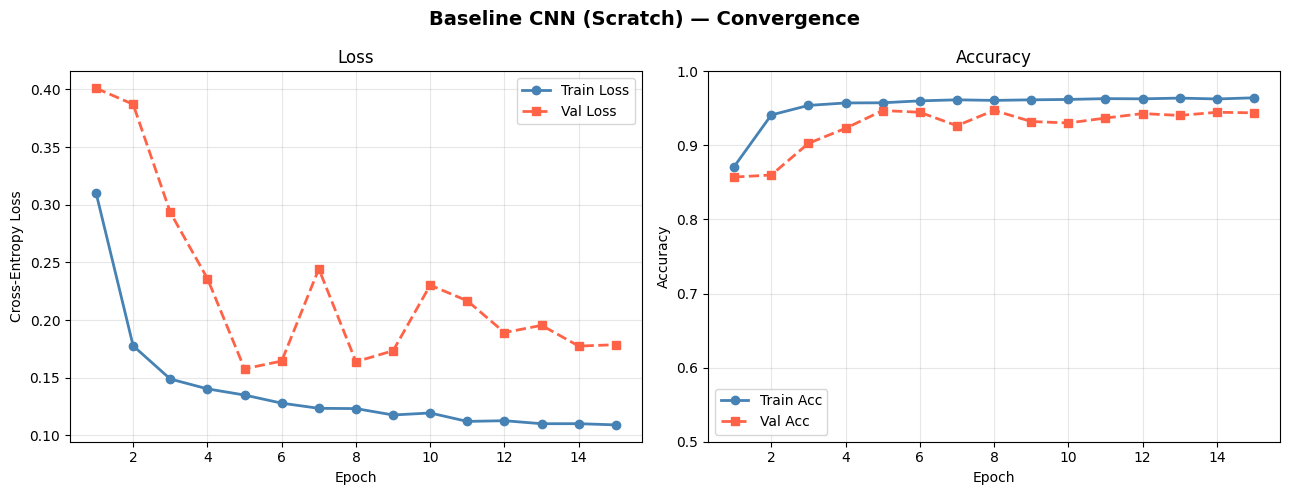

Final Train Loss: 0.1092 | Final Train Acc: 0.9643
Final Val   Loss: 0.1787  | Final Val   Acc: 0.9440
Train-Val Accuracy Gap: 0.0203 (well-generalized)


In [ ]:
# -- Plot convergence -----------------------------------------------
epochs = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Baseline CNN (Scratch) — Convergence', fontsize=14, fontweight='bold')

# Loss
axes[0].plot(epochs, cnn_train_losses, 'o-', color='steelblue',  label='Train Loss', linewidth=2)
axes[0].plot(epochs, cnn_val_losses,   's--', color='tomato',    label='Val Loss',   linewidth=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs, cnn_train_accs, 'o-',  color='steelblue', label='Train Acc', linewidth=2)
axes[1].plot(epochs, cnn_val_accs,   's--', color='tomato',    label='Val Acc',   linewidth=2)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_ylim(0.5, 1.0)

plt.tight_layout()
plt.savefig('cnn_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

# Print final stats
print(f'Final Train Loss: {cnn_train_losses[-1]:.4f} | Final Train Acc: {cnn_train_accs[-1]:.4f}')
print(f'Final Val   Loss: {cnn_val_losses[-1]:.4f}  | Final Val   Acc: {cnn_val_accs[-1]:.4f}')
gap = cnn_train_accs[-1] - cnn_val_accs[-1]
print(f'Train-Val Accuracy Gap: {gap:.4f} {"(overfitting)" if gap > 0.05 else "(well-generalized)"}')



### Convergence
- Training loss decreases steadily and reaches ~0.12 within 10 epochs, confirming that the model converges. This is expected since we used a small model trained on 19k images. Train accuracy increased to slightly above the validation accuracy after epoch 5, coming to about 2.03% higher. This may be slightly overfit, however a 2.03% training-validation gap is small enough to consider the model well-generalized, though some mild overfitting may be present given the model has no held-out regularization pressure beyond Dropout and BatchNorm. This behavior does not surprise us for the baseline built from scratch and it serves as a good comparison floor for the transfer learning experiments.

Prompt: "Evaluate the baseline CNN on the test set and report the accuracy, F1, recall, precision, ROC-AUC, classification report, and confusion matrix. Visualize and save the confusion matrix."

  Baseline CNN — Test Set Results
  Accuracy  : 0.9498
  F1 Score  : 0.9518  (pos=Parasitized)
  Recall    : 0.9245  (sensitivity)
  Precision : 0.9809
  ROC-AUC   : 0.9878

Confusion Matrix:
  TN= 2016  FP=   43
  FN=  180  TP= 2203

Classification Report:
              precision    recall  f1-score   support

  Uninfected       0.92      0.98      0.95      2059
 Parasitized       0.98      0.92      0.95      2383

    accuracy                           0.95      4442
   macro avg       0.95      0.95      0.95      4442
weighted avg       0.95      0.95      0.95      4442



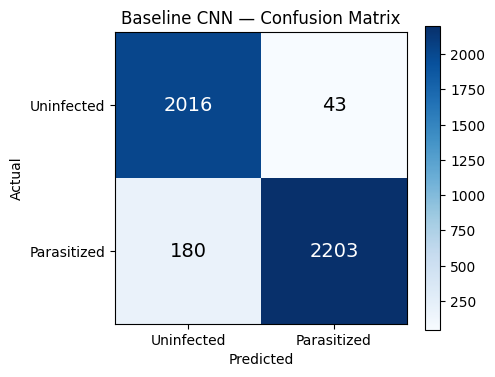

In [ ]:
# -- Evaluate baseline CNN on test set --------------------------------------
from sklearn.metrics import (accuracy_score, f1_score, recall_score,
                              precision_score, roc_auc_score,
                              confusion_matrix, classification_report)

baseline_cnn.eval()
all_preds_cnn, all_labels_cnn, all_probs_cnn = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        logits = baseline_cnn(images)
        probs  = torch.softmax(logits, dim=1)
        preds  = probs.argmax(dim=1)
        all_preds_cnn.extend(preds.cpu().numpy())
        all_labels_cnn.extend(labels.numpy())
        all_probs_cnn.extend(probs[:, 1].cpu().numpy())

all_preds_cnn  = np.array(all_preds_cnn)
all_labels_cnn = np.array(all_labels_cnn)
all_probs_cnn  = np.array(all_probs_cnn)

# Metrics
baseline_acc  = accuracy_score(all_labels_cnn, all_preds_cnn)
baseline_f1   = f1_score(all_labels_cnn, all_preds_cnn, pos_label=1)
baseline_rec  = recall_score(all_labels_cnn, all_preds_cnn, pos_label=1)
baseline_prec = precision_score(all_labels_cnn, all_preds_cnn, pos_label=1)
baseline_auc  = roc_auc_score(all_labels_cnn, all_probs_cnn)
cm            = confusion_matrix(all_labels_cnn, all_preds_cnn)

print('='*55)
print('  Baseline CNN — Test Set Results')
print('='*55)
print(f'  Accuracy  : {baseline_acc:.4f}')
print(f'  F1 Score  : {baseline_f1:.4f}  (pos=Parasitized)')
print(f'  Recall    : {baseline_rec:.4f}  (sensitivity)')
print(f'  Precision : {baseline_prec:.4f}')
print(f'  ROC-AUC   : {baseline_auc:.4f}')
print('='*55)
print(f'\nConfusion Matrix:')
print(f'  TN={cm[0,0]:5d}  FP={cm[0,1]:5d}')
print(f'  FN={cm[1,0]:5d}  TP={cm[1,1]:5d}')
print()
print('Classification Report:')
print(classification_report(all_labels_cnn, all_preds_cnn,
                             target_names=['Uninfected', 'Parasitized']))

# Visualise confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Uninfected', 'Parasitized'])
ax.set_yticklabels(['Uninfected', 'Parasitized'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=14)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Baseline CNN — Confusion Matrix')
plt.tight_layout()
plt.savefig('cnn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 5 — Transfer Learning: Bottleneck Features

### How we extract bottleneck features
- Instead of training the whole model, we freeze it and train the head. So we are not running all images once, saving their features and reusing them. We send images through the model every time we train. First, the model looks at the batch of images and pass them through the frozen backbone. This processes the images but doesn't learn anything new. Next, we grab the important output (the CLS token, which is a 192-number summary of the image) and pass that into the head. As a result, only the head gets updated. This method is slower but now we can apply random changes to the images each time, like flipping or rotating them. The model sees slightly different versions of the same image every epoch, which improves the learning power, which works in our data since orientation does not matter in pictures of malaria in cells.

Prompt: "Using Hugging Face and PyTorch, load the dataset, freeze the entire backbone, replace the classifier with a 2-class head, and create 224x224 ImageNet-normalized dataloaders for train/val/test. Print frozen vs trainable paramater counts."

In [ ]:
# -- Build transfer learning model (DeiT-tiny frozen backbone + 2-class head) --
from transformers import ViTForImageClassification, ViTImageProcessor
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader

# -- Hyperparameters -----------------------------------------------
TL_IMG_SIZE   = 224      # DeiT requires 224×224
TL_BATCH_SIZE = 32       # smaller batch for larger images
TL_EPOCHS     = 10
TL_LR         = 1e-3

# -- Load DeiT-tiny backbone -----------------------------------------------
model_name = 'facebook/deit-tiny-patch16-224'
deit = ViTForImageClassification.from_pretrained(model_name)

# Freeze ALL backbone parameters
for param in deit.parameters():
    param.requires_grad = False

# Replace the 1000-class ImageNet head with a 2-class malaria head
hidden_size    = deit.config.hidden_size   # 192 for DeiT-tiny
deit.classifier = nn.Linear(hidden_size, NUM_CLASSES)
# Only the new head is trainable — backbone stays frozen

deit = deit.to(DEVICE)

frozen    = sum(p.numel() for p in deit.parameters() if not p.requires_grad)
trainable = sum(p.numel() for p in deit.parameters() if p.requires_grad)
total     = frozen + trainable

print(f'Model: {model_name}')
print(f'Hidden size: {hidden_size} | Encoder layers: {deit.config.num_hidden_layers}')
print(f'Total parameters:     {total:,}')
print(f'Frozen parameters:    {frozen:,}  (entire DeiT backbone)')
print(f'Trainable parameters: {trainable:,}  (new 2-class head only)')

# -- DataLoaders for DeiT (224×224, ImageNet normalisation) -----------------
# DeiT expects the same normalisation used during its ImageNet pre-training
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

tl_train_transform = transforms.Compose([
    transforms.Resize((TL_IMG_SIZE, TL_IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

tl_val_transform = transforms.Compose([
    transforms.Resize((TL_IMG_SIZE, TL_IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

tl_train_dataset = MalariaDataset(train_imgs, train_lbls, transform=tl_train_transform)
tl_val_dataset   = MalariaDataset(val_imgs,   val_lbls,   transform=tl_val_transform)
tl_test_dataset  = MalariaDataset(test_imgs,  test_lbls,  transform=tl_val_transform)

tl_train_loader = DataLoader(tl_train_dataset, batch_size=TL_BATCH_SIZE, shuffle=True,
                             num_workers=2, pin_memory=True)
tl_val_loader   = DataLoader(tl_val_dataset,   batch_size=TL_BATCH_SIZE, shuffle=False,
                             num_workers=2, pin_memory=True)
tl_test_loader  = DataLoader(tl_test_dataset,  batch_size=TL_BATCH_SIZE, shuffle=False,
                             num_workers=2, pin_memory=True)

print(f'\nDataLoaders ready (224×224, ImageNet normalisation)')
print(f'Train batches: {len(tl_train_loader)} | Val: {len(tl_val_loader)} | Test: {len(tl_test_loader)}')


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Model: facebook/deit-tiny-patch16-224
Hidden size: 192 | Encoder layers: 12
Total parameters:     5,524,802
Frozen parameters:    5,524,416  (entire DeiT backbone)
Trainable parameters: 386  (new 2-class head only)

DataLoaders ready (224×224, ImageNet normalisation)
Train batches: 563 | Val: 161 | Test: 139


Prompt: "Train only the new classification head for 10 epochs using Adam, Cross-entropy loss, and StepLR. Note train/val loss and accuracy per epoch and total training time."

In [ ]:
# -- Train bottleneck TL model -----------------------------------------------
optimizer_tl = torch.optim.Adam(
    filter(lambda p: p.requires_grad, deit.parameters()),
    lr=TL_LR
)
scheduler_tl = torch.optim.lr_scheduler.StepLR(optimizer_tl, step_size=3, gamma=0.5)
loss_fn_tl   = nn.CrossEntropyLoss()

tl_train_losses, tl_val_losses = [], []
tl_train_accs,   tl_val_accs   = [], []

t0 = time.time()

for epoch in range(1, TL_EPOCHS + 1):
    # -- Training pass -----------------------------------------------
    deit.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in tl_train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer_tl.zero_grad()

        outputs = deit(images)          # returns SequenceClassifierOutput
        logits  = outputs.logits        # shape: (B, 2)
        loss    = loss_fn_tl(logits, labels)
        loss.backward()
        optimizer_tl.step()

        running_loss += loss.item() * images.size(0)
        preds         = logits.argmax(dim=1)
        correct      += (preds == labels).sum().item()
        total        += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total
    scheduler_tl.step()

    # -- Validation pass -----------------------------------------------
    deit.eval()
    val_loss_sum, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in tl_val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = deit(images)
            logits  = outputs.logits
            loss    = loss_fn_tl(logits, labels)
            val_loss_sum += loss.item() * images.size(0)
            preds  = logits.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total   += labels.size(0)

    val_loss = val_loss_sum / val_total
    val_acc  = val_correct / val_total

    tl_train_losses.append(train_loss)
    tl_val_losses.append(val_loss)
    tl_train_accs.append(train_acc)
    tl_val_accs.append(val_acc)

    print(f'Epoch [{epoch:02d}/{TL_EPOCHS}]  '
          f'Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f}  '
          f'Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.4f}')

tl_time = time.time() - t0
print(f'\nTraining complete in {tl_time:.1f}s ({tl_time/60:.1f} min)')


Epoch [01/10]  Train Loss: 0.1678  Train Acc: 0.9426  Val Loss: 0.1913  Val Acc: 0.9336
Epoch [02/10]  Train Loss: 0.1296  Train Acc: 0.9573  Val Loss: 0.1687  Val Acc: 0.9418
Epoch [03/10]  Train Loss: 0.1251  Train Acc: 0.9573  Val Loss: 0.1558  Val Acc: 0.9444
Epoch [04/10]  Train Loss: 0.1214  Train Acc: 0.9592  Val Loss: 0.1791  Val Acc: 0.9389
Epoch [05/10]  Train Loss: 0.1205  Train Acc: 0.9586  Val Loss: 0.1900  Val Acc: 0.9371
Epoch [06/10]  Train Loss: 0.1187  Train Acc: 0.9600  Val Loss: 0.1557  Val Acc: 0.9453
Epoch [07/10]  Train Loss: 0.1176  Train Acc: 0.9596  Val Loss: 0.1739  Val Acc: 0.9405
Epoch [08/10]  Train Loss: 0.1178  Train Acc: 0.9595  Val Loss: 0.1701  Val Acc: 0.9420
Epoch [09/10]  Train Loss: 0.1169  Train Acc: 0.9607  Val Loss: 0.1808  Val Acc: 0.9387
Epoch [10/10]  Train Loss: 0.1148  Train Acc: 0.9604  Val Loss: 0.1710  Val Acc: 0.9416

Training complete in 476.7s (7.9 min)


Prompt: "Plot bottleneck convergence with both baseline and validation curves. Evaluate on test set with prior metrics used, print the baseline vs bottleneck comparisons, and show side by side confusion matrices."

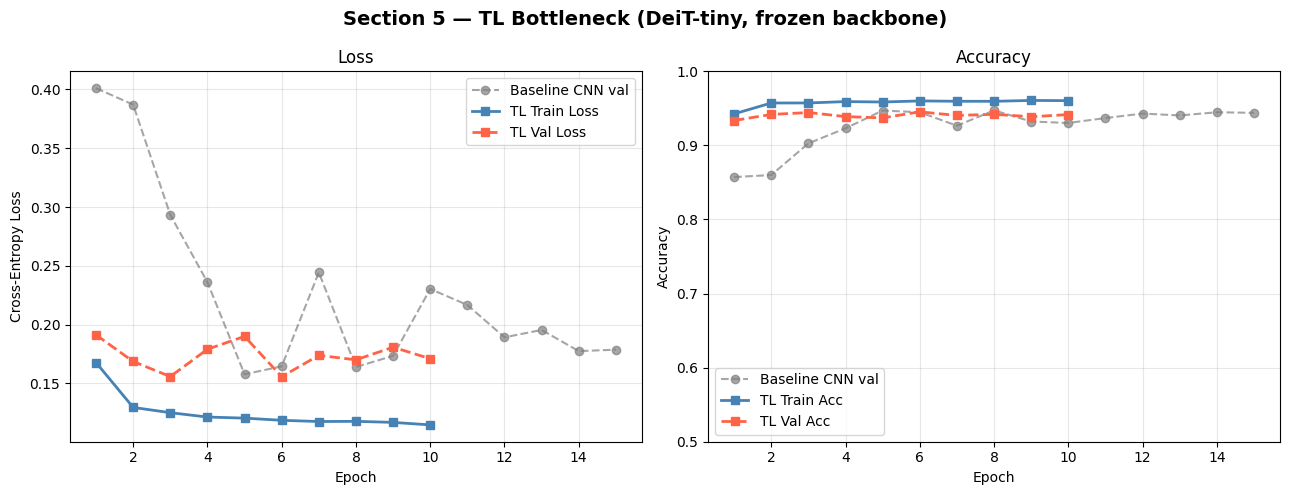

Final TL Train Loss: 0.1148 | Train Acc: 0.9604
Final TL Val   Loss: 0.1710  | Val   Acc: 0.9416
Train-Val Accuracy Gap: 0.0188 (well-generalised)

  TL Bottleneck (DeiT-tiny) — Test Set Results
  Accuracy  : 0.9511   (Baseline: 0.9498)
  F1 Score  : 0.9535   (Baseline: 0.9518)
  Recall    : 0.9341   (Baseline: 0.9245)
  Precision : 0.9738   (Baseline: 0.9809)
  ROC-AUC   : 0.9819   (Baseline: 0.9878)

Confusion Matrix:
  TN= 1999  FP=   60
  FN=  157  TP= 2226

Classification Report:
              precision    recall  f1-score   support

  Uninfected       0.93      0.97      0.95      2059
 Parasitized       0.97      0.93      0.95      2383

    accuracy                           0.95      4442
   macro avg       0.95      0.95      0.95      4442
weighted avg       0.95      0.95      0.95      4442



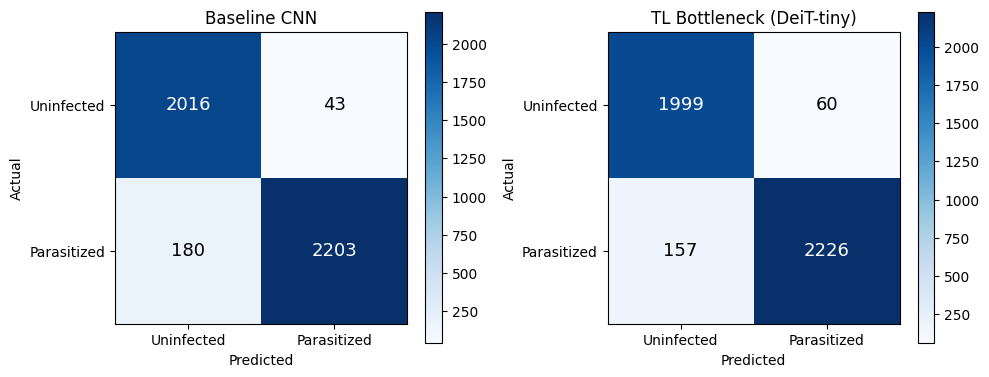

In [ ]:
# -- Plot convergence + evaluate on test set ----------------------------------
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (accuracy_score, f1_score, recall_score,
                              precision_score, roc_auc_score,
                              confusion_matrix, classification_report)

# -- Convergence curves -----------------------------------------------
epochs_tl = range(1, TL_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Section 5 — TL Bottleneck (DeiT-tiny, frozen backbone)', fontsize=14, fontweight='bold')

# Loss — show both CNN baseline and TL on same plot for comparison
axes[0].plot(range(1, NUM_EPOCHS + 1), cnn_val_losses,  'o--', color='grey',      label='Baseline CNN val',  linewidth=1.5, alpha=0.7)
axes[0].plot(epochs_tl,                tl_train_losses,  's-',  color='steelblue', label='TL Train Loss',     linewidth=2)
axes[0].plot(epochs_tl,                tl_val_losses,    's--', color='tomato',    label='TL Val Loss',       linewidth=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(range(1, NUM_EPOCHS + 1), cnn_val_accs,   'o--', color='grey',      label='Baseline CNN val',  linewidth=1.5, alpha=0.7)
axes[1].plot(epochs_tl,               tl_train_accs,   's-',  color='steelblue', label='TL Train Acc',      linewidth=2)
axes[1].plot(epochs_tl,               tl_val_accs,     's--', color='tomato',    label='TL Val Acc',        linewidth=2)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_ylim(0.5, 1.0)

plt.tight_layout()
plt.savefig('tl_bottleneck_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Final TL Train Loss: {tl_train_losses[-1]:.4f} | Train Acc: {tl_train_accs[-1]:.4f}')
print(f'Final TL Val   Loss: {tl_val_losses[-1]:.4f}  | Val   Acc: {tl_val_accs[-1]:.4f}')
tl_gap = tl_train_accs[-1] - tl_val_accs[-1]
print(f'Train-Val Accuracy Gap: {tl_gap:.4f} {"(overfitting)" if tl_gap > 0.05 else "(well-generalised)"}')

# -- Test evaluation -----------------------------------------------
deit.eval()
all_preds_tl, all_labels_tl, all_probs_tl = [], [], []

with torch.no_grad():
    for images, labels in tl_test_loader:
        images = images.to(DEVICE)
        logits = deit(images).logits
        probs  = torch.softmax(logits, dim=1)
        preds  = probs.argmax(dim=1)
        all_preds_tl.extend(preds.cpu().numpy())
        all_labels_tl.extend(labels.numpy())
        all_probs_tl.extend(probs[:, 1].cpu().numpy())

all_preds_tl  = np.array(all_preds_tl)
all_labels_tl = np.array(all_labels_tl)
all_probs_tl  = np.array(all_probs_tl)

tl_acc  = accuracy_score(all_labels_tl, all_preds_tl)
tl_f1   = f1_score(all_labels_tl, all_preds_tl, pos_label=1)
tl_rec  = recall_score(all_labels_tl, all_preds_tl, pos_label=1)
tl_prec = precision_score(all_labels_tl, all_preds_tl, pos_label=1)
tl_auc  = roc_auc_score(all_labels_tl, all_probs_tl)
tl_cm   = confusion_matrix(all_labels_tl, all_preds_tl)

print('\n' + '='*55)
print('  TL Bottleneck (DeiT-tiny) — Test Set Results')
print('='*55)
print(f'  Accuracy  : {tl_acc:.4f}   (Baseline: {baseline_acc:.4f})')
print(f'  F1 Score  : {tl_f1:.4f}   (Baseline: {baseline_f1:.4f})')
print(f'  Recall    : {tl_rec:.4f}   (Baseline: {baseline_rec:.4f})')
print(f'  Precision : {tl_prec:.4f}   (Baseline: {baseline_prec:.4f})')
print(f'  ROC-AUC   : {tl_auc:.4f}   (Baseline: {baseline_auc:.4f})')
print('='*55)
print(f'\nConfusion Matrix:')
print(f'  TN={tl_cm[0,0]:5d}  FP={tl_cm[0,1]:5d}')
print(f'  FN={tl_cm[1,0]:5d}  TP={tl_cm[1,1]:5d}')
print()
print('Classification Report:')
print(classification_report(all_labels_tl, all_preds_tl,
                             target_names=['Uninfected', 'Parasitized']))

# -- Side-by-side confusion matrices -----------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, cm_data, title in [
    (axes[0], confusion_matrix(all_labels_cnn, all_preds_cnn), 'Baseline CNN'),
    (axes[1], tl_cm, 'TL Bottleneck (DeiT-tiny)'),
]:
    im = ax.imshow(cm_data, interpolation='nearest', cmap='Blues')
    plt.colorbar(im, ax=ax)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Uninfected', 'Parasitized'])
    ax.set_yticklabels(['Uninfected', 'Parasitized'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm_data[i, j]), ha='center', va='center',
                    color='white' if cm_data[i, j] > cm_data.max() / 2 else 'black', fontsize=13)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(title)

plt.tight_layout()
plt.savefig('tl_vs_baseline_confusion.png', dpi=150, bbox_inches='tight')
plt.show()



### Model convergence and comparison
- Yes, the model converges because the frozen DeiT backbone provides strong, pretrained representations, and the head only needs to learn a linear mapping that splits the 192 dimension feature vectors into different classes. The model converged earlier than the CNN, which needed more epochs to learn useful filters from scratch. The bottleneck model achieves a slightly higher accuracy (0.9511) than the baseline CNN (0.9498), though its ROC-AUC is slightly lower (0.9819 compared to 0.9878). This mixed result makes sense because ImageNet pretraining gives the frozen backbone strong general features like edges and textures. However, the images of the cells are visually different from ImageNet's natural photos. Since the backbone is completely frozen, it cannot adapt its representations to the specific color distributions or features unique to malaria-infected cells. The result here is a model that improves on coarse accuracy, but doesn't fully close the gap in AUC. This is why fine-tuning is necessary.

---
## Section 6 — Fine-Tuning

### Fine-Tuning Method
We started from the bottleneck-trained DeiT-tiny model and froze the whole model, then unfroze the classifier head, the final normalization layer, and the last two encoder blocks. This lets the model adapt higher features to malaria cells while keeping most of the backbone stable. We used AdamW with a smaller learning rate (1e-5) for the backbone and a larger learning rate (5e-5) for the new head. Because of heardware constraints the batch size is 16 with gradient checkpointing



In [ ]:
'''
PROMPT: Asked ChatGPT to generate code (based on prior code from bottleneck DeiT model) to set up the fine tune model based on the above fine tuning method.

'''
# -- Section 6: Fine-tuning setup
import copy
import gc
from contextlib import nullcontext

# Save the bottleneck-trained state BEFORE unfreezing anything
bottleneck_state_before_ft = {k: v.detach().cpu().clone() for k, v in deit.state_dict().items()}

# Keep earlier metrics/objects under clear names for Section 7
baseline_cm = cm.copy()
baseline_total_params = sum(p.numel() for p in baseline_cnn.parameters())
baseline_trainable_params = sum(p.numel() for p in baseline_cnn.parameters() if p.requires_grad)

bottleneck_total_params = sum(p.numel() for p in deit.parameters())
bottleneck_trainable_params = sum(p.numel() for p in deit.classifier.parameters())  # head only

# Fine-tuning hyperparameters
FT_BATCH_SIZE   = 16          # smaller than bottleneck stage to reduce memory use
FT_EPOCHS       = 10
FT_BACKBONE_LR  = 1e-5        # lower LR for pre-trained layers
FT_HEAD_LR      = 5e-5        # slightly higher LR for new classifier head
FT_WEIGHT_DECAY = 1e-4
UNFREEZE_LAST_N = 2           # unfreeze last 2 transformer blocks

# Fine-tuning DataLoaders (same transforms as TL, smaller batch)
ft_train_dataset = MalariaDataset(train_imgs, train_lbls, transform=tl_train_transform)
ft_val_dataset   = MalariaDataset(val_imgs,   val_lbls,   transform=tl_val_transform)
ft_test_dataset  = MalariaDataset(test_imgs,  test_lbls,  transform=tl_val_transform)

ft_train_loader = DataLoader(
    ft_train_dataset, batch_size=FT_BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True
)
ft_val_loader = DataLoader(
    ft_val_dataset, batch_size=FT_BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True
)
ft_test_loader = DataLoader(
    ft_test_dataset, batch_size=FT_BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True
)

# Freeze everything first
for param in deit.parameters():
    param.requires_grad = False

# Unfreeze classifier head
for param in deit.classifier.parameters():
    param.requires_grad = True

# Unfreeze final layer norm
if hasattr(deit.vit, "layernorm"):
    for param in deit.vit.layernorm.parameters():
        param.requires_grad = True

# Unfreeze last N encoder blocks
for block in deit.vit.encoder.layer[-UNFREEZE_LAST_N:]:
    for param in block.parameters():
        param.requires_grad = True

ft_used_gradient_checkpointing = False
if hasattr(deit, "gradient_checkpointing_enable"):
    try:
        deit.gradient_checkpointing_enable()
        ft_used_gradient_checkpointing = True
    except Exception:
        ft_used_gradient_checkpointing = False

# Parameter groups: lower LR for backbone, slightly higher LR for head
head_params = list(deit.classifier.parameters())
backbone_params = []

if hasattr(deit.vit, "layernorm"):
    backbone_params += list(deit.vit.layernorm.parameters())
for block in deit.vit.encoder.layer[-UNFREEZE_LAST_N:]:
    backbone_params += list(block.parameters())

# De-duplicate parameters
seen = set()
backbone_params_unique = []
for p in backbone_params:
    if id(p) not in seen:
        backbone_params_unique.append(p)
        seen.add(id(p))

head_params_unique = []
for p in head_params:
    if id(p) not in seen:
        head_params_unique.append(p)
        seen.add(id(p))
    elif id(p) in [id(x) for x in head_params]:
        head_params_unique.append(p)

optimizer_ft = torch.optim.AdamW(
    [
        {"params": backbone_params_unique, "lr": FT_BACKBONE_LR},
        {"params": deit.classifier.parameters(), "lr": FT_HEAD_LR},
    ],
    weight_decay=FT_WEIGHT_DECAY
)

scheduler_ft = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_ft, mode="min", factor=0.5, patience=1
)
loss_fn_ft = nn.CrossEntropyLoss()

use_amp = DEVICE.type == "cuda"
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

fine_tune_total_params = sum(p.numel() for p in deit.parameters())
fine_tune_trainable_params = sum(p.numel() for p in deit.parameters() if p.requires_grad)

print("=" * 70)
print("SECTION 6 — FINE-TUNING CONFIGURATION")
print("=" * 70)
print(f"Unfrozen layers        : classifier + final layernorm + last {UNFREEZE_LAST_N} encoder blocks")
print(f"Backbone LR            : {FT_BACKBONE_LR}")
print(f"Head LR                : {FT_HEAD_LR}")
print(f"Batch size             : {FT_BATCH_SIZE}")
print(f"Gradient checkpointing : {ft_used_gradient_checkpointing}")
print(f"Mixed precision (AMP)  : {use_amp}")
print(f"Trainable parameters   : {fine_tune_trainable_params:,}")
print(f"Total parameters       : {fine_tune_total_params:,}")
print(f"Train batches          : {len(ft_train_loader)} | Val batches: {len(ft_val_loader)} | Test batches: {len(ft_test_loader)}")

SECTION 6 — FINE-TUNING CONFIGURATION
Unfrozen layers        : classifier + final layernorm + last 2 encoder blocks
Backbone LR            : 1e-05
Head LR                : 5e-05
Batch size             : 16
Gradient checkpointing : True
Mixed precision (AMP)  : True
Trainable parameters   : 890,498
Total parameters       : 5,524,802
Train batches          : 1125 | Val batches: 321 | Test batches: 278


In [ ]:

'''
PROMPT: Following generating the previous code, asked ChatGPT to generate code to train the fine tune model and to plot the
training/validation loss and accuracy, as well as the performance metrics as done in the prior code (of the bottleneck DeiT model evaluation)

'''
# -- Section 6: Fine-tuning training loop -----------------------------------------------
ft_train_losses, ft_val_losses = [], []
ft_train_accs,   ft_val_accs   = [], []
ft_epoch_times = []

best_ft_state = None
best_ft_val_loss = float("inf")
best_ft_epoch = -1

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

t0 = time.time()

for epoch in range(1, FT_EPOCHS + 1):
    epoch_start = time.time()

    # ---- Train ----
    deit.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in ft_train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer_ft.zero_grad(set_to_none=True)

        amp_ctx = torch.autocast(device_type="cuda", dtype=torch.float16) if use_amp else nullcontext()
        with amp_ctx:
            outputs = deit(images)
            logits = outputs.logits
            loss = loss_fn_ft(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer_ft)
        torch.nn.utils.clip_grad_norm_(deit.parameters(), max_norm=1.0)
        scaler.step(optimizer_ft)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # ---- Validate ----
    deit.eval()
    val_loss_sum, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in ft_val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            amp_ctx = torch.autocast(device_type="cuda", dtype=torch.float16) if use_amp else nullcontext()
            with amp_ctx:
                outputs = deit(images)
                logits = outputs.logits
                loss = loss_fn_ft(logits, labels)

            val_loss_sum += loss.item() * images.size(0)
            preds = logits.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss_sum / val_total
    val_acc = val_correct / val_total

    ft_train_losses.append(train_loss)
    ft_val_losses.append(val_loss)
    ft_train_accs.append(train_acc)
    ft_val_accs.append(val_acc)

    scheduler_ft.step(val_loss)

    if val_loss < best_ft_val_loss:
        best_ft_val_loss = val_loss
        best_ft_epoch = epoch
        best_ft_state = {k: v.detach().cpu().clone() for k, v in deit.state_dict().items()}

    epoch_time = time.time() - epoch_start
    ft_epoch_times.append(epoch_time)

    current_lrs = [group["lr"] for group in optimizer_ft.param_groups]
    print(
        f"Epoch [{epoch:02d}/{FT_EPOCHS}]  "
        f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f}  "
        f"Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.4f}  "
        f"LRs: {[f'{lr:.2e}' for lr in current_lrs]}  "
        f"Time: {epoch_time:.1f}s"
    )

ft_time = time.time() - t0
ft_peak_gpu_mem_mb = (
    torch.cuda.max_memory_allocated() / (1024 ** 2)
    if DEVICE.type == "cuda" else np.nan
)

# Restore best fine-tuned checkpoint
if best_ft_state is not None:
    deit.load_state_dict(best_ft_state)

print("\n" + "=" * 70)
print("FINE-TUNING COMPLETE")
print("=" * 70)
print(f"Best epoch             : {best_ft_epoch}")
print(f"Best validation loss   : {best_ft_val_loss:.4f}")
print(f"Total fine-tune time   : {ft_time:.1f}s ({ft_time/60:.2f} min)")
if DEVICE.type == "cuda":
    print(f"Peak GPU memory        : {ft_peak_gpu_mem_mb:.1f} MB")
else:
    print("Peak GPU memory        : N/A (CPU run)")

Epoch [01/10]  Train Loss: 0.1224  Train Acc: 0.9602  Val Loss: 0.2104  Val Acc: 0.9418  LRs: ['1.00e-05', '5.00e-05']  Time: 48.0s
Epoch [02/10]  Train Loss: 0.1196  Train Acc: 0.9627  Val Loss: 0.1738  Val Acc: 0.9473  LRs: ['1.00e-05', '5.00e-05']  Time: 47.6s
Epoch [03/10]  Train Loss: 0.1155  Train Acc: 0.9630  Val Loss: 0.1792  Val Acc: 0.9465  LRs: ['1.00e-05', '5.00e-05']  Time: 47.8s
Epoch [04/10]  Train Loss: 0.1133  Train Acc: 0.9651  Val Loss: 0.1702  Val Acc: 0.9483  LRs: ['1.00e-05', '5.00e-05']  Time: 49.3s
Epoch [05/10]  Train Loss: 0.1083  Train Acc: 0.9661  Val Loss: 0.1627  Val Acc: 0.9496  LRs: ['1.00e-05', '5.00e-05']  Time: 48.8s
Epoch [06/10]  Train Loss: 0.1040  Train Acc: 0.9667  Val Loss: 0.1922  Val Acc: 0.9485  LRs: ['1.00e-05', '5.00e-05']  Time: 48.5s
Epoch [07/10]  Train Loss: 0.1027  Train Acc: 0.9674  Val Loss: 0.1835  Val Acc: 0.9520  LRs: ['5.00e-06', '2.50e-05']  Time: 48.4s
Epoch [08/10]  Train Loss: 0.0979  Train Acc: 0.9688  Val Loss: 0.1674  Val 

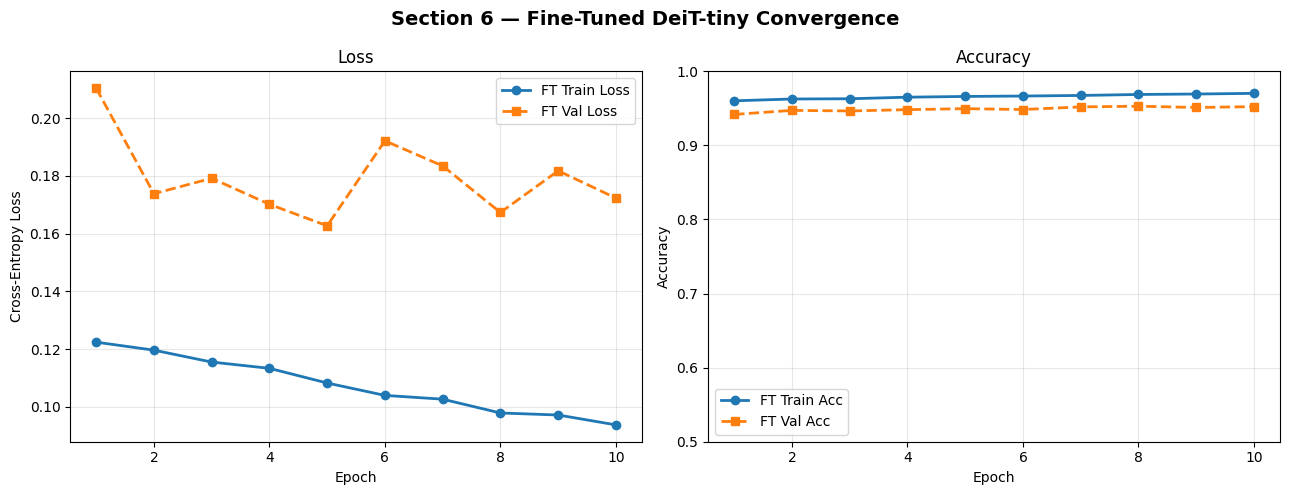

  Fine-Tuned DeiT-tiny — Test Set Results
  Accuracy  : 0.9552
  F1 Score  : 0.9576  (pos=Parasitized)
  Recall    : 0.9429  (sensitivity)
  Precision : 0.9727
  ROC-AUC   : 0.9864

Confusion Matrix:
  TN= 1996  FP=   63
  FN=  136  TP= 2247

Classification Report:
              precision    recall  f1-score   support

  Uninfected       0.94      0.97      0.95      2059
 Parasitized       0.97      0.94      0.96      2383

    accuracy                           0.96      4442
   macro avg       0.95      0.96      0.96      4442
weighted avg       0.96      0.96      0.96      4442



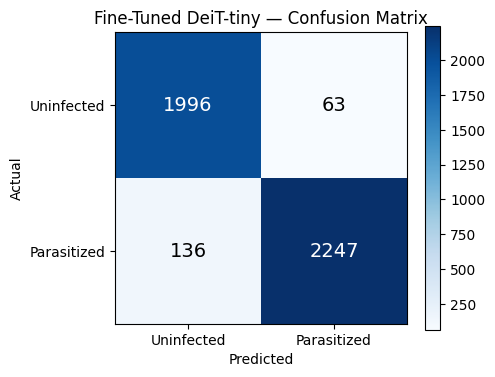

Final FT Train Loss: 0.0938 | Train Acc: 0.9703
Final FT Val   Loss: 0.1723  | Val   Acc: 0.9524
Train-Val Accuracy Gap: 0.0179 (well-generalized)


In [ ]:
epochs_ft = range(1, FT_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Section 6 — Fine-Tuned DeiT-tiny Convergence", fontsize=14, fontweight="bold")

axes[0].plot(epochs_ft, ft_train_losses, "o-", label="FT Train Loss", linewidth=2)
axes[0].plot(epochs_ft, ft_val_losses,   "s--", label="FT Val Loss", linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].set_title("Loss")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(epochs_ft, ft_train_accs, "o-", label="FT Train Acc", linewidth=2)
axes[1].plot(epochs_ft, ft_val_accs,   "s--", label="FT Val Acc", linewidth=2)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy")
axes[1].set_ylim(0.5, 1.0)
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig("fine_tuned_deit_convergence.png", dpi=150, bbox_inches="tight")
plt.show()

# Test evaluation
deit.eval()
all_preds_ft, all_labels_ft, all_probs_ft = [], [], []

with torch.no_grad():
    for images, labels in ft_test_loader:
        images = images.to(DEVICE)
        logits = deit(images).logits
        probs  = torch.softmax(logits, dim=1)
        preds  = probs.argmax(dim=1)

        all_preds_ft.extend(preds.cpu().numpy())
        all_labels_ft.extend(labels.numpy())
        all_probs_ft.extend(probs[:, 1].cpu().numpy())

all_preds_ft  = np.array(all_preds_ft)
all_labels_ft = np.array(all_labels_ft)
all_probs_ft  = np.array(all_probs_ft)

ft_acc  = accuracy_score(all_labels_ft, all_preds_ft)
ft_f1   = f1_score(all_labels_ft, all_preds_ft, pos_label=1)
ft_rec  = recall_score(all_labels_ft, all_preds_ft, pos_label=1)
ft_prec = precision_score(all_labels_ft, all_preds_ft, pos_label=1)
ft_auc  = roc_auc_score(all_labels_ft, all_probs_ft)
ft_cm   = confusion_matrix(all_labels_ft, all_preds_ft)

print("=" * 55)
print("  Fine-Tuned DeiT-tiny — Test Set Results")
print("=" * 55)
print(f"  Accuracy  : {ft_acc:.4f}")
print(f"  F1 Score  : {ft_f1:.4f}  (pos=Parasitized)")
print(f"  Recall    : {ft_rec:.4f}  (sensitivity)")
print(f"  Precision : {ft_prec:.4f}")
print(f"  ROC-AUC   : {ft_auc:.4f}")
print("=" * 55)
print(f"\nConfusion Matrix:")
print(f"  TN={ft_cm[0,0]:5d}  FP={ft_cm[0,1]:5d}")
print(f"  FN={ft_cm[1,0]:5d}  TP={ft_cm[1,1]:5d}")
print()
print("Classification Report:")
print(classification_report(
    all_labels_ft, all_preds_ft,
    target_names=["Uninfected", "Parasitized"],
    zero_division=0
))

# Fine-tuned confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(ft_cm, interpolation="nearest", cmap="Blues")
plt.colorbar(im, ax=ax)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["Uninfected", "Parasitized"])
ax.set_yticklabels(["Uninfected", "Parasitized"])
for i in range(2):
    for j in range(2):
        ax.text(
            j, i, str(ft_cm[i, j]),
            ha="center", va="center",
            color="white" if ft_cm[i, j] > ft_cm.max()/2 else "black",
            fontsize=14
        )
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Fine-Tuned DeiT-tiny — Confusion Matrix")
plt.tight_layout()
plt.savefig("fine_tuned_deit_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

ft_gap = ft_train_accs[-1] - ft_val_accs[-1]
print(f"Final FT Train Loss: {ft_train_losses[-1]:.4f} | Train Acc: {ft_train_accs[-1]:.4f}")
print(f"Final FT Val   Loss: {ft_val_losses[-1]:.4f}  | Val   Acc: {ft_val_accs[-1]:.4f}")
print(f"Train-Val Accuracy Gap: {ft_gap:.4f} {'(overfitting)' if ft_gap > 0.05 else '(well-generalized)'}")

### Fine-Tuning Results
#### Model Convergence
The model did converge. The training loss decreased steadily from 0.1224 to 0.0938 and the training accuracy rose from 0.9602 to 0.9703 over 10 epochs. We also see the validation performance improve with the loss dropping from 0.2104 to 0.1723 and accuraxy increase from 0.9418 to 0.9524. The validation loss does fluncuate a bit in the later epochs, but the overal trend shows stable learning.

#### Model Performance
The fine-tuned model performed well on the test set with a 0.9552 accuracy, 0.9576 F1-Score, 0.9429 recall, 0.9727 precision, and 0.9864 ROC-AUC. More on the comparison and results in the next section.

---
## Section 7 — Results, Comparisons & Statistical Tests  

,Model,Accuracy,F1,Recall,Precision,ROC_AUC,Train_Time_s,Train_Time_min,Total_Params,Trainable_Params,Model_Size_MB,Observed_Peak_GPU_MB
0,Baseline CNN (scratch),0.9498,0.9518,0.9245,0.9809,0.9878,356.8,5.95,332674,332674,1.27,nan
1,DeiT bottleneck,0.9511,0.9535,0.9341,0.9738,0.9819,476.7,7.95,5524802,386,21.08,nan
2,DeiT fine-tuned,0.9552,0.9576,0.9429,0.9727,0.9864,483.8,8.06,5524802,890498,21.08,103.9


SECTION 7 — SUMMARY TABLE
Highest test accuracy : DeiT fine-tuned
Highest test recall   : DeiT fine-tuned

Note: exact peak GPU memory was recorded only for Section 6 fine-tuning,
because Sections 4–5 had already finished training before profiling was added.

PAIRWISE ACCURACY COMPARISONS — McNEMAR EXACT TEST
Bonferroni-corrected alpha for 3 comparisons: 0.0167


,Comparison,A_correct_B_wrong,A_wrong_B_correct,Discordant_Total,McNemar_p,Significant_at_0.05,Significant_Bonferroni
0,Baseline CNN (scratch) vs DeiT bottleneck,56,62,118,0.645497,False,False
1,Baseline CNN (scratch) vs DeiT fine-tuned,46,70,116,0.032272,True,False
2,DeiT bottleneck vs DeiT fine-tuned,9,27,36,0.003933,True,True



PAIRED BOOTSTRAP COMPARISONS — METRIC DIFFERENCE CIs


,Comparison,Accuracy_Diff,Accuracy_95CI,F1_Diff,F1_95CI,Recall_Diff,Recall_95CI,Precision_Diff,Precision_95CI
0,DeiT bottleneck - Baseline CNN (scratch),0.0013,"[-0.0036, 0.0061]",0.0017,"[-0.0031, 0.0063]",0.0096,"[0.0021, 0.0171]",-0.0071,"[-0.0120, -0.0024]"
1,DeiT fine-tuned - Baseline CNN (scratch),0.0054,"[0.0005, 0.0101]",0.0058,"[0.0010, 0.0105]",0.0184,"[0.0111, 0.0258]",-0.0081,"[-0.0129, -0.0035]"
2,DeiT fine-tuned - DeiT bottleneck,0.0040,"[0.0014, 0.0068]",0.0041,"[0.0015, 0.0067]",0.0088,"[0.0049, 0.0131]",-0.0011,"[-0.0040, 0.0016]"


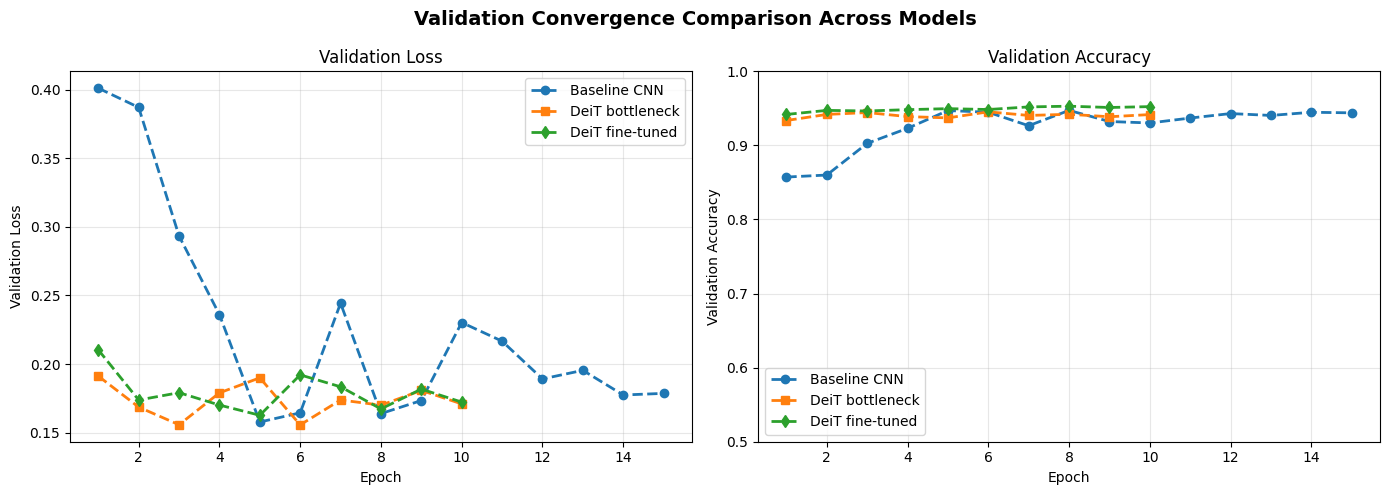

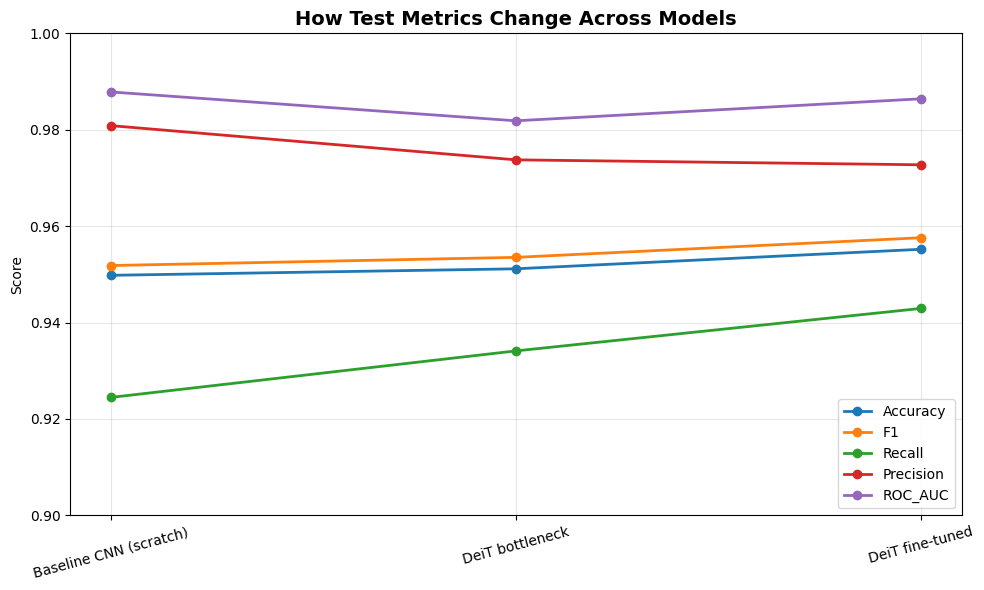

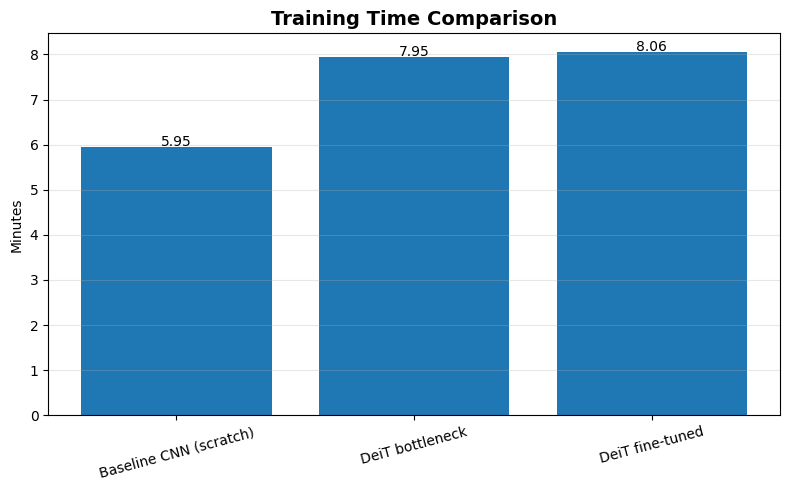

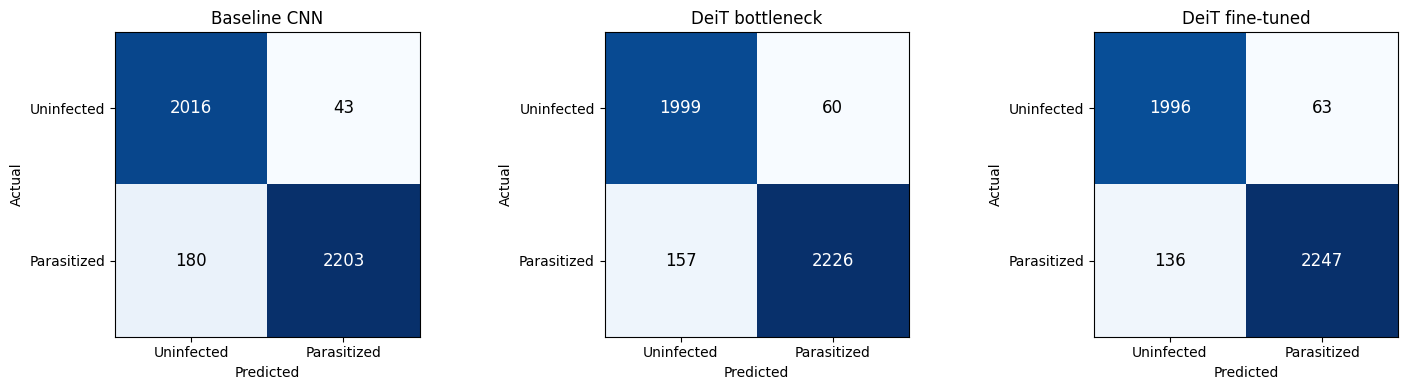

In [ ]:
'''
PROMPT: Asked ChatGPT using the prior model evaluation code for the prior three models, generate code to compare the convergence, performance metrics, and time of the models
using tables and plots. I also told it to compare the models using staistical tests, including McNemar's test and paired bootstrap CI.

'''

# ── Section 7: Results table + statistical comparisons + cleaner visuals ─────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binomtest
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

# Sanity check: all models must be evaluated on the same test labels in the same order
assert np.array_equal(all_labels_cnn, all_labels_tl), "Baseline and bottleneck test label orders do not match."
assert np.array_equal(all_labels_cnn, all_labels_ft), "Baseline and fine-tuned test label orders do not match."

def model_size_mb(model):
    param_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
    buffer_bytes = sum(b.numel() * b.element_size() for b in model.buffers())
    return (param_bytes + buffer_bytes) / (1024 ** 2)

# ------------------------------------------------------------------
# Results summary table
# ------------------------------------------------------------------
results_df = pd.DataFrame([
    {
        "Model": "Baseline CNN (scratch)",
        "Accuracy": baseline_acc,
        "F1": baseline_f1,
        "Recall": baseline_rec,
        "Precision": baseline_prec,
        "ROC_AUC": baseline_auc,
        "Train_Time_s": baseline_time,
        "Train_Time_min": baseline_time / 60,
        "Total_Params": baseline_total_params,
        "Trainable_Params": baseline_trainable_params,
        "Model_Size_MB": model_size_mb(baseline_cnn),
        "Observed_Peak_GPU_MB": np.nan,  # not captured during earlier training
    },
    {
        "Model": "DeiT bottleneck",
        "Accuracy": tl_acc,
        "F1": tl_f1,
        "Recall": tl_rec,
        "Precision": tl_prec,
        "ROC_AUC": tl_auc,
        "Train_Time_s": tl_time,
        "Train_Time_min": tl_time / 60,
        "Total_Params": bottleneck_total_params,
        "Trainable_Params": bottleneck_trainable_params,
        "Model_Size_MB": model_size_mb(deit),
        "Observed_Peak_GPU_MB": np.nan,  # not captured during earlier training
    },
    {
        "Model": "DeiT fine-tuned",
        "Accuracy": ft_acc,
        "F1": ft_f1,
        "Recall": ft_rec,
        "Precision": ft_prec,
        "ROC_AUC": ft_auc,
        "Train_Time_s": ft_time,
        "Train_Time_min": ft_time / 60,
        "Total_Params": fine_tune_total_params,
        "Trainable_Params": fine_tune_trainable_params,
        "Model_Size_MB": model_size_mb(deit),
        "Observed_Peak_GPU_MB": ft_peak_gpu_mem_mb,
    },
])

display(results_df.style.format({
    "Accuracy": "{:.4f}",
    "F1": "{:.4f}",
    "Recall": "{:.4f}",
    "Precision": "{:.4f}",
    "ROC_AUC": "{:.4f}",
    "Train_Time_s": "{:.1f}",
    "Train_Time_min": "{:.2f}",
    "Model_Size_MB": "{:.2f}",
    "Observed_Peak_GPU_MB": "{:.1f}",
}))

best_by_accuracy = results_df.loc[results_df["Accuracy"].idxmax(), "Model"]
best_by_recall   = results_df.loc[results_df["Recall"].idxmax(), "Model"]

print("=" * 70)
print("SECTION 7 — SUMMARY TABLE")
print("=" * 70)
print(f"Highest test accuracy : {best_by_accuracy}")
print(f"Highest test recall   : {best_by_recall}")
print("\nNote: exact peak GPU memory was recorded only for Section 6 fine-tuning,")
print("because Sections 4–5 had already finished training before profiling was added.")

# ------------------------------------------------------------------
# Proper statistical comparisons
# ------------------------------------------------------------------
def mcnemar_exact_test(y_true, pred_a, pred_b, model_a="Model A", model_b="Model B"):
    """
    Exact McNemar test on paired predictions.
    Tests whether the two classifiers have the same error rate on the same examples.
    """
    y_true = np.asarray(y_true)
    pred_a = np.asarray(pred_a)
    pred_b = np.asarray(pred_b)

    a_correct = pred_a == y_true
    b_correct = pred_b == y_true

    # Discordant counts
    b = np.sum(a_correct & ~b_correct)   # A correct, B wrong
    c = np.sum(~a_correct & b_correct)   # A wrong, B correct
    n = b + c

    p_value = 1.0 if n == 0 else binomtest(min(b, c), n=n, p=0.5, alternative="two-sided").pvalue

    return {
        "Comparison": f"{model_a} vs {model_b}",
        "A_correct_B_wrong": int(b),
        "A_wrong_B_correct": int(c),
        "Discordant_Total": int(n),
        "McNemar_p": p_value
    }

def paired_bootstrap_metric_diff(y_true, pred_a, pred_b, metric_fn, n_boot=3000, seed=42):
    """
    Paired bootstrap CI for metric difference: metric(B) - metric(A)
    """
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    pred_a = np.asarray(pred_a)
    pred_b = np.asarray(pred_b)
    n = len(y_true)

    diffs = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        diff = metric_fn(y_true[idx], pred_b[idx]) - metric_fn(y_true[idx], pred_a[idx])
        diffs.append(diff)

    diffs = np.array(diffs)
    return {
        "mean_diff": diffs.mean(),
        "ci_low": np.percentile(diffs, 2.5),
        "ci_high": np.percentile(diffs, 97.5)
    }

# Metric functions
acc_fn  = lambda y, p: accuracy_score(y, p)
f1_fn   = lambda y, p: f1_score(y, p, pos_label=1, zero_division=0)
rec_fn  = lambda y, p: recall_score(y, p, pos_label=1, zero_division=0)
prec_fn = lambda y, p: precision_score(y, p, pos_label=1, zero_division=0)

pairwise_models = [
    ("Baseline CNN (scratch)", all_preds_cnn, "DeiT bottleneck", all_preds_tl),
    ("Baseline CNN (scratch)", all_preds_cnn, "DeiT fine-tuned", all_preds_ft),
    ("DeiT bottleneck",        all_preds_tl,  "DeiT fine-tuned", all_preds_ft),
]

# McNemar table
mcnemar_rows = []
for name_a, pred_a, name_b, pred_b in pairwise_models:
    row = mcnemar_exact_test(all_labels_cnn, pred_a, pred_b, name_a, name_b)
    mcnemar_rows.append(row)

mcnemar_df = pd.DataFrame(mcnemar_rows)

# Bonferroni correction for 3 pairwise tests
alpha = 0.05
bonf_alpha = alpha / len(pairwise_models)
mcnemar_df["Significant_at_0.05"] = mcnemar_df["McNemar_p"] < alpha
mcnemar_df["Significant_Bonferroni"] = mcnemar_df["McNemar_p"] < bonf_alpha

print("\n" + "=" * 70)
print("PAIRWISE ACCURACY COMPARISONS — McNEMAR EXACT TEST")
print("=" * 70)
print(f"Bonferroni-corrected alpha for 3 comparisons: {bonf_alpha:.4f}")
display(mcnemar_df.style.format({"McNemar_p": "{:.6f}"}))

# Paired bootstrap CI table
bootstrap_rows = []
for name_a, pred_a, name_b, pred_b in pairwise_models:
    acc_ci  = paired_bootstrap_metric_diff(all_labels_cnn, pred_a, pred_b, acc_fn)
    f1_ci   = paired_bootstrap_metric_diff(all_labels_cnn, pred_a, pred_b, f1_fn)
    rec_ci  = paired_bootstrap_metric_diff(all_labels_cnn, pred_a, pred_b, rec_fn)
    prec_ci = paired_bootstrap_metric_diff(all_labels_cnn, pred_a, pred_b, prec_fn)

    bootstrap_rows.append({
        "Comparison": f"{name_b} - {name_a}",
        "Accuracy_Diff": acc_ci["mean_diff"],
        "Accuracy_95CI": f"[{acc_ci['ci_low']:.4f}, {acc_ci['ci_high']:.4f}]",
        "F1_Diff": f1_ci["mean_diff"],
        "F1_95CI": f"[{f1_ci['ci_low']:.4f}, {f1_ci['ci_high']:.4f}]",
        "Recall_Diff": rec_ci["mean_diff"],
        "Recall_95CI": f"[{rec_ci['ci_low']:.4f}, {rec_ci['ci_high']:.4f}]",
        "Precision_Diff": prec_ci["mean_diff"],
        "Precision_95CI": f"[{prec_ci['ci_low']:.4f}, {prec_ci['ci_high']:.4f}]",
    })

bootstrap_df = pd.DataFrame(bootstrap_rows)

print("\n" + "=" * 70)
print("PAIRED BOOTSTRAP COMPARISONS — METRIC DIFFERENCE CIs")
print("=" * 70)
display(bootstrap_df.style.format({
    "Accuracy_Diff": "{:.4f}",
    "F1_Diff": "{:.4f}",
    "Recall_Diff": "{:.4f}",
    "Precision_Diff": "{:.4f}",
}))

# ------------------------------------------------------------------
# Visual comparisons across all three models
# ------------------------------------------------------------------

# 1) Overlaid validation convergence curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Validation Convergence Comparison Across Models", fontsize=14, fontweight="bold")

axes[0].plot(range(1, NUM_EPOCHS + 1), cnn_val_losses, "o--", label="Baseline CNN", linewidth=2)
axes[0].plot(range(1, TL_EPOCHS + 1),  tl_val_losses,  "s--", label="DeiT bottleneck", linewidth=2)
axes[0].plot(range(1, FT_EPOCHS + 1),  ft_val_losses,  "d--", label="DeiT fine-tuned", linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Validation Loss")
axes[0].set_title("Validation Loss")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(range(1, NUM_EPOCHS + 1), cnn_val_accs, "o--", label="Baseline CNN", linewidth=2)
axes[1].plot(range(1, TL_EPOCHS + 1),  tl_val_accs,  "s--", label="DeiT bottleneck", linewidth=2)
axes[1].plot(range(1, FT_EPOCHS + 1),  ft_val_accs,  "d--", label="DeiT fine-tuned", linewidth=2)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation Accuracy")
axes[1].set_title("Validation Accuracy")
axes[1].set_ylim(0.5, 1.0)
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig("all_models_validation_convergence.png", dpi=150, bbox_inches="tight")
plt.show()

# 2) Easier-to-read metric trend chart across models (replaces grouped bar chart)
metrics_to_plot = ["Accuracy", "F1", "Recall", "Precision", "ROC_AUC"]
model_order = results_df["Model"].tolist()

fig, ax = plt.subplots(figsize=(10, 6))
for metric in metrics_to_plot:
    ax.plot(model_order, results_df[metric], marker="o", linewidth=2, label=metric)

ax.set_title("How Test Metrics Change Across Models", fontsize=14, fontweight="bold")
ax.set_ylabel("Score")
ax.set_ylim(0.90, 1.00)   # zoomed in so small differences are visible
ax.grid(alpha=0.3)
ax.legend(loc="lower right")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("metric_trends_across_models.png", dpi=150, bbox_inches="tight")
plt.show()

# 3) Runtime comparison
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(results_df["Model"], results_df["Train_Time_min"])
ax.set_title("Training Time Comparison", fontsize=14, fontweight="bold")
ax.set_ylabel("Minutes")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=15)
for i, v in enumerate(results_df["Train_Time_min"]):
    ax.text(i, v + 0.02, f"{v:.2f}", ha="center")
plt.tight_layout()
plt.savefig("training_time_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# 4) Confusion matrices side-by-side
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
cms = [
    (baseline_cm, "Baseline CNN"),
    (tl_cm,       "DeiT bottleneck"),
    (ft_cm,       "DeiT fine-tuned"),
]

for ax, (cm_data, title) in zip(axes, cms):
    im = ax.imshow(cm_data, interpolation="nearest", cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Uninfected", "Parasitized"])
    ax.set_yticklabels(["Uninfected", "Parasitized"])
    for i in range(2):
        for j in range(2):
            ax.text(
                j, i, str(cm_data[i, j]),
                ha="center", va="center",
                color="white" if cm_data[i, j] > cm_data.max()/2 else "black",
                fontsize=12
            )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)

plt.tight_layout()
plt.savefig("all_models_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

### Results of Models
Reminder of our metrics: accuracy is the primary metric because of the nature of it being a balanced dataset and for the models' overall correctness in cell classification, and recall to evaluate limiting missing infections, as well as other performance metrics like F1, precision, and ROC-AUC:
* The __baseline CNN__ performed strongly for a base modoel with having the highest precision (0.9809) and fewest false positives (43), but its weakness was its recall, missing 180 parasitized cells on the test set, the highest false negative rate of the models.
* The __DeiT bottleneck__ performance improved slightly from the CNN, especially on recall, reducing the false negatives from 180 to 157 (recall from 0.9245 to 0.9341), withich is useful for screening but it did with slightly lower precision (0.9809 to 0.9738). It also did have the lowest ROC-AUC of 0.9819.
* The __fine-tuned DeiT__ had the best accuracy (0.9552), highest F1 (0.9576), and highest recall (0.9429). Most importantly for the malaria screening case, it had the loswest msised infections at 136 false negatives for the test set, but it did have the lowest precision of slightly lower than the bottleneck (0.9727).

See the visualization above for how the different performance metrics varied by models as desribed above.

### Convergence, Runtime/Memory
All three models converged, but the traning behaviors difer a bit between the models:
* The __baseline CNN__ converged but the validation loss was the most unstable. It improved over time while training, reaching 0.9498 in accuracy, but the curve was noisier.
* The __DeiT bottleneck__ converged faster and more smoothly than the CNN. For most of the training it stayed between around 0.94-0.95 and the loss stayed more stable than CNN.
* The __fine-tuned DeiT__ converged pretty smoothly and had the strongest validation performance overall, remaining around 0.95 in accuracy and having a low train-validation gap.

There are convergence plots above showing the validation loss and accuracy for reference.

Runtime/Memory
* The baseline was the fastest and smallest model by far, taking only nearly 6 min to train and being 1.27MB in size. The DeiT models were both 21MB in size, with the bottleneck taking nearlu 8 mins to train and the fine-tuned tkaing just a bit more time, 8.06 mins. The peak GPU usage for the largest model bu size and traininable/total parameters, the fine-tuned DeiT, had a peak GPU usage of 103.9 MB, so its clear the transformer models are more resource insensive compared to the CNN.

There are plots above for training time comparisons, as well as information in the opening table for model size and paramater counts.

### Statistical Comparisons
McNemar's Test
* __Baseline CNN vs DeiT bottleneck__: p = 0.6455. This is not statistically significant at the p = 0.05 lebel, their accuracy is too similar to conclude one is better than others based on paired test predictions.
* __Baseline CNN vs DeiT fine-tuned__: p = 0.0323. This is statistically signisicant at the p = 0.0t threshold, but not significant after the Bonferroni correction (0.0167). So the fine-tuned model looks better than the baseline but the paired accurecy evidence is only moderate once multiple comparisons are controlled.
* __DeiT bottleneck vs DeiT fine-tuned__: p = 0.0039. This is statistically significant, even after the Bonferoni correction, so fine-tuning is a much better improvement over the bottleneck model.

Paired Bootstrap Confidence Intervals
* __DeiT bottleneck - Baseline CNN__
  * Accuracy difference: +0.0013, 95% CI [-0.0036, 0.0061]
  * F1 difference: +0.0017, 95% CI [-0.0031, 0.0063]
  * Recall difference: +0.0096, 95% CI [0.0021, 0.0171]
  * Precision difference: -0.0071, 95% CI [-0.0120, -0.0024]

  By these methods, it shows the bottleneck model didn't statistically improve accuracy or F1, but did improve recall but lower precision

* __Deit fine-tuned - Baseline CNN__
  * Accuracy difference: +0.0054, 95% CI [0.0005, 0.0101]
  * F1 difference: +0.0058, 95% CI [0.0010, 0.0105]
  * Recall difference: +0.0184, 95% CI [0.0111, 0.0258]
  * Precision difference: -0.0081, 95% CI [-0.0129, -0.0035]

  By these methods, it shows the fine-tuned model shows clear gains in accuracy, F1, and recall over the CNN, but the precision drop is staistically significant.  

* __Deit fine-tuned - DeiT bottleneck__
  * Accuracy difference: +0.0040, 95% CI [0.0014, 0.0068]
  * F1 difference: +0.0041, 95% CI [0.0015, 0.0067]
  * Recall difference: +0.0088, 95% CI [0.0049, 0.0131]
  * Precision difference: -0.0011, 95% CI [-0.0040, 0.0016]

  By these methods, it is clear that fine-tuning has improvements in accuracy, F1, and recall like it did over the CNN, but for this one the precision was not statistically different.

### Fine-Tuning, Use-Case, Advantages/Limitations
Overall, fine-tuning performed well on the dataset and does supprt the policy case. As we previously discussed, for malaria screening false negativs are more costly than false positives because missing an infected cell can delay treatment. For that, the fine-tuned model is the strongest of the three models, having the highest recall and the fewest false negatives. This would make it best for things like autimated assistance for microscope screenings where the tool prioritizes catching infected cells even if it needs more follow up review. In this experiment, the fine-tuned model reduced false negatives from 180 to 136 versus the baseline CNN.

Main advantages:
* best accuracy, F1, and recall
* Strongest overal screening behavior on test set
* Statistically significant improvement ober bottleneck model
* Better domain adaption than the frozen-natire transfer model alone

Main limitations:
* Lower precision than the baseline CNN, so more false positives
* Much larger model size and compute cost than the CNN
* Validation is still needed in order to generalize to other microscopes and hosptial practices.

Overall, by the objectives the fine-tuned DeiT is the best model, while the baseline CNN is still a good option with better speed, size, and precision. But the fine-tuned offers, overall, the best performance in the most critical areas while having the best balance in other metrics.


References:

https://www.kaggle.com/datasets/iarunava/cell-images-for-detecting-malaria

https://lhncbc.nlm.nih.gov/LHC-downloads/dataset.html

https://peerj.com/articles/4568/

https://huggingface.co/facebook/deit-tiny-patch16-224

https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html